Importando bibliotecas:

In [2]:
#carregando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
from datetime import datetime


Fase 1: Análise Exploratória de Dados (EDA)

Estatística Descritiva: Apresente de forma explícita as dimensões do dataset (linhas e colunas), os tipos primitivos das variáveis carregadas e o resumo estatístico descritivo das colunas numéricas (usando o método .describe()).
Visualização de Dados: plote, no mínimo, 3 gráficos analíticos, por exemplo: histograma da distribuição da variável-alvo (avalie também sua assimetria), gráficos de dispersão entre ao menos duas variáveis explicativas e a variável-alvo, e um mapa de calor da correlação de Pearson entre as variáveis numéricas (retomando o conceito de multicolinearidade já trabalhado).
Análise Textual: insira uma célula de texto que explique, de forma crítica, os achados das análises visuais e estatísticas, indicando como esses padrões orientarão suas escolhas de modelagem (ou explique tudo isso no seu vídeo).


In [345]:
#carregando o dataset
df = pd.read_csv("../data/raw/spanish_houses.csv")

FileNotFoundError: [Errno 2] No such file or directory: '../data/raw/spanish_houses.csv'

In [3]:
#dimensões do dataset
print("Número de linhas:", df.shape[0])
print("Número de colunas:", df.shape[1])

Número de linhas: 100000
Número de colunas: 41


In [4]:
#Tipos de variáveis e informações gerais do dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 41 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   ad_description                 95426 non-null   str    
 1   ad_last_update                 100000 non-null  str    
 2   air_conditioner                100000 non-null  str    
 3   balcony                        100000 non-null  str    
 4   bath_num                       100000 non-null  str    
 5   built_in_wardrobe              100000 non-null  str    
 6   chimney                        100000 non-null  str    
 7   condition                      86059 non-null   str    
 8   construct_date                 32059 non-null   str    
 9   energetic_certif               74691 non-null   str    
 10  floor                          79693 non-null   str    
 11  garage                         40811 non-null   str    
 12  garden                         100000 non-

In [5]:
#estatisticas descritivas do dataset
df.describe()

,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
count,100000.000000,1.000000e+05,100000.000000,100000.000000,59280.00000
mean,100050.342090,1.320589e+06,3.000553,2.827112,11864.35119
std,114436.597411,1.379332e+06,3.429043,2.952647,9980.43530
min,5689.000000,8.860000e+04,0.170000,0.190000,21.61300
25%,49582.000000,7.205920e+05,1.490000,1.540000,22.82200
50%,75628.000000,1.128908e+06,2.270000,2.420000,19818.00000
75%,96638.000000,1.149628e+06,2.900000,2.460000,19818.00000
max,538917.000000,6.578079e+06,16.150000,14.080000,21714.00000


In [6]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ad_description,95426,86150,ad_description,183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ad_last_update,100000,369,más de 5 meses sin actualizar,3208,NaN,NaN,NaN,NaN,NaN,NaN,NaN
air_conditioner,100000,3,0,76867,NaN,NaN,NaN,NaN,NaN,NaN,NaN
balcony,100000,3,0,81668,NaN,NaN,NaN,NaN,NaN,NaN,NaN
bath_num,100000,30,2,40556,NaN,NaN,NaN,NaN,NaN,NaN,NaN
built_in_wardrobe,100000,3,0,57444,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chimney,100000,3,0,96132,NaN,NaN,NaN,NaN,NaN,NaN,NaN
condition,86059,4,segunda mano/buen estado,72272,NaN,NaN,NaN,NaN,NaN,NaN,NaN
construct_date,32059,355,2007,1031,NaN,NaN,NaN,NaN,NaN,NaN,NaN
energetic_certif,74691,4,en trámite,46957,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
#valores ausentes por coluna
df.isnull().sum().sort_values(ascending=False)

ground_size                      99817
unfurnished                      99354
kitchen                          97788
loc_street                       85686
heating                          74286
construct_date                   67941
orientation                      60585
garage                           59189
loc_neigh                        56310
m2_useful                        47156
lift                             41035
renta_media_prov                 40720
energetic_certif                 25309
floor                            20307
condition                        13941
loc_district                     13747
ad_description                    4574
price                                0
population_prov_vs_national_%        0
companies_prov_vs_national_%         0
population_prov                      0
number_of_companies_prov             0
air_conditioner                      0
terrace                              0
swimming_pool                        0
storage_room             

In [8]:
#percentual de valores ausentes por coluna
percentual_nulos = (df.isnull().sum() / len(df)) * 100

nulos = pd.DataFrame({
    'Valores Nulos': df.isnull().sum(),
    'Percentual (%)': percentual_nulos.round(2)
})

nulos.sort_values('Percentual (%)', ascending=False)

,Valores Nulos,Percentual (%)
ground_size,99817,99.82
unfurnished,99354,99.35
kitchen,97788,97.79
loc_street,85686,85.69
heating,74286,74.29
construct_date,67941,67.94
orientation,60585,60.58
garage,59189,59.19
loc_neigh,56310,56.31
m2_useful,47156,47.16


## Análise Inicial

O conjunto de dados apresenta aproximadamente 100 mil registros contendo informações sobre imóveis localizados na Espanha. As variáveis incluem características físicas dos imóveis, localização, infraestrutura e indicadores socioeconômicos das províncias. A análise dos tipos de dados mostrou a presença de variáveis numéricas, categóricas e booleanas, sendo necessária a conversão de algumas colunas originalmente importadas como texto.

## Análise de valores ausentes

A análise dos valores ausentes mostrou que o conjunto de dados possui variáveis com diferentes níveis de completude. Observa-se que algumas colunas apresentam mais de 90% de informações ausentes, como **ground_size (99,82%)**, **unfurnished (99,35%)** e **kitchen (97,79%)**. Além disso, **loc_street (85,69%)** e **heating (74,29%)** também possuem um percentual elevado de valores nulos.

Considerando que essas variáveis possuem quantidade insuficiente de informações para representar adequadamente o conjunto de dados, optou-se por removê-las da análise. A manutenção dessas colunas exigiria imputações em larga escala, aumentando o risco de introduzir vieses e reduzindo a confiabilidade do modelo preditivo.

Algumas variáveis apresentam percentual intermediário de valores ausentes, como **construct_date (67,94%)**, **orientation (60,58%)**, **garage (59,19%)**, **loc_neigh (56,31%)**, **m2_useful (47,16%)** e **lift (41,04%)**. Essas colunas foram analisadas individualmente quanto à sua relevância para a previsão do preço dos imóveis. As variáveis consideradas importantes para o modelo foram mantidas e seus valores ausentes tratados por meio de técnicas de imputação adequadas ou criação da categoria "Não Informado", quando categóricas.

Por outro lado, variáveis com baixo percentual de dados ausentes, como **condition (13,94%)**, **loc_district (13,75%)** e **ad_description (4,57%)**, foram mantidas, pois a quantidade reduzida de valores faltantes permite um tratamento simples sem comprometer significativamente a qualidade das informações.




## Visualização de Dados:

Plote, no mínimo, 3 gráficos analíticos, por exemplo: histograma da distribuição da variável-alvo (avalie também sua assimetria), gráficos de dispersão entre ao menos duas variáveis explicativas e a variável-alvo, e um mapa de calor da correlação de Pearson entre as variáveis numéricas (retomando o conceito de multicolinearidade já trabalhado).


In [9]:
import os


os.makedirs("../outputs/figures", exist_ok=True)



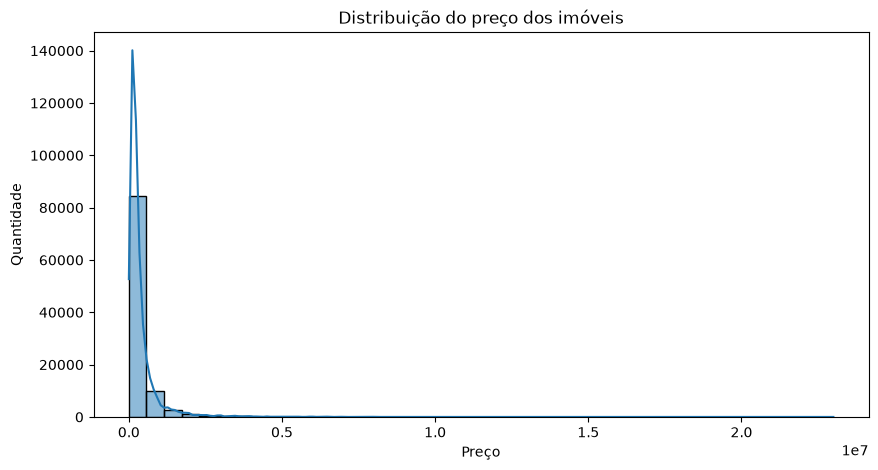

In [84]:
plt.figure(figsize=(10,5))

sns.histplot(
    data=df_tratado,
    x="price",
    bins=40,
    kde=True
)

plt.title("Distribuição do preço dos imóveis")
plt.xlabel("Preço")
plt.ylabel("Quantidade")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

plt.show()


## Anáilise descritiva:

A Figura acima apresenta a distribuição da variável-alvo (`price`) por meio de um histograma acompanhado de uma curva de densidade (Kernel Density Estimation – KDE). Observa-se uma elevada concentração de imóveis em faixas de menor preço, evidenciada pelo pico acentuado no início da distribuição. À medida que o preço aumenta, a frequência das observações diminui rapidamente, formando uma longa cauda à direita.

Esse comportamento caracteriza uma distribuição fortemente assimétrica à direita (assimetria positiva), fato confirmado pelo coeficiente de assimetria obtido para a variável (`Skewness = 7,45`), que será mostrada a seguir. A presença de poucos imóveis com preços muito elevados amplia significativamente a dispersão da variável e faz com que grande parte das observações fique concentrada nas menores faixas de preço.

Essa característica é comum em bases de dados do mercado imobiliário, nas quais coexistem imóveis populares e propriedades de alto padrão. Entretanto, distribuições altamente assimétricas podem dificultar o ajuste de modelos preditivos, principalmente aqueles baseados em relações lineares, devido à elevada influência exercida pelos valores extremos.

Dessa forma, optou-se por aplicar a transformação logarítmica da variável `price`, gerando a variável `price_log`. Essa transformação reduz a assimetria da distribuição, diminui o impacto dos imóveis de maior valor e produz uma variável resposta mais adequada para o treinamento e avaliação dos modelos de aprendizado de máquina.

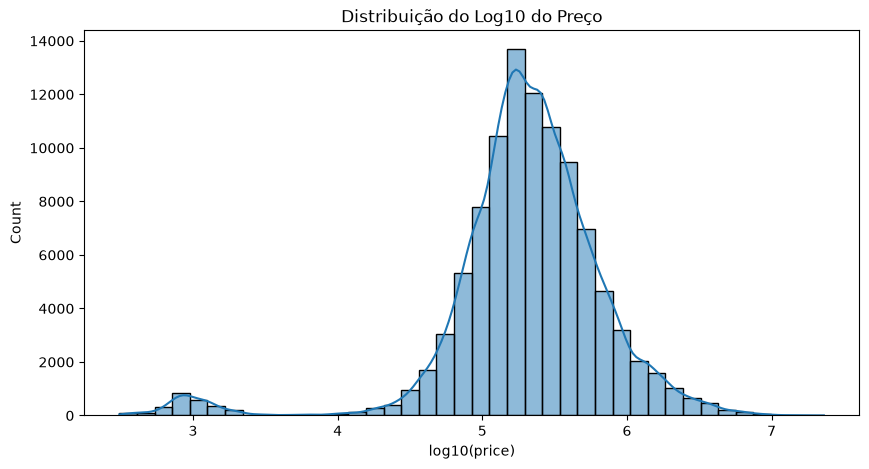

In [85]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    np.log10(df_tratado["price"]),
    bins=40,
    kde=True
)

plt.title("Distribuição do Log10 do Preço")
plt.xlabel("log10(price)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco_log.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Distribuição da variável-alvo após transformação logarítmica

A Figura acima apresenta a distribuição da variável-alvo após a aplicação da transformação logarítmica na base 10 (`log10(price)`). Em comparação com a distribuição original, observa-se uma redução expressiva da assimetria positiva, resultando em uma distribuição significativamente mais equilibrada.

O maior número de observações concentra-se aproximadamente entre os valores 5,0 e 5,5 da escala logarítmica, formando uma distribuição unimodal e relativamente próxima de uma distribuição normal. Embora ainda exista uma discreta assimetria à direita, sua intensidade é muito inferior à observada na variável original.

Também é possível identificar um pequeno agrupamento de observações em torno de `log10(price) ≈ 3`, correspondente a um número reduzido de imóveis com preços significativamente inferiores ao restante da amostra. Como essas observações representam uma pequena parcela do conjunto de dados, seu impacto sobre a distribuição geral é limitado.

A transformação logarítmica distribuiu melhor os valores ao longo do eixo horizontal, reduzindo o efeito dos imóveis de maior valor e facilitando a visualização da estrutura da variável resposta. Essa transformação também diminuiu a influência dos valores extremos durante a modelagem, contribuindo para um ajuste mais estável dos algoritmos de regressão.

Os resultados obtidos durante a etapa de modelagem confirmaram essa melhoria, uma vez que o Random Forest treinado utilizando a variável transformada apresentou melhor desempenho preditivo em comparação ao treinamento realizado diretamente na escala original dos preços.

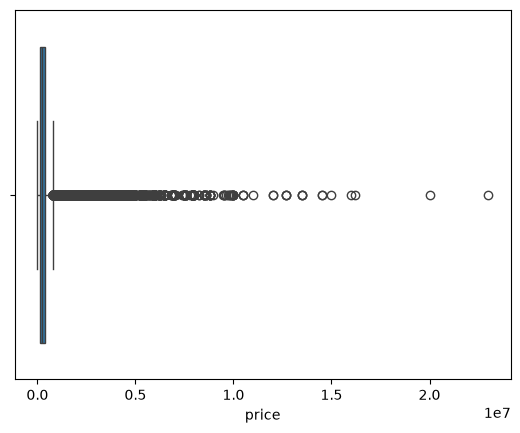

In [86]:
#Boxplot para visualizar a distribuição do preço dos imóveis
sns.boxplot(x=df_tratado["price"])


# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_preco.png",
    dpi=300,
    bbox_inches="tight"
)

# Exibe o gráfico
plt.show()

plt.show()

## Análise do Boxplot do Preço (Escala Log10)

O boxplot da variável `price` em escala logarítmica apresenta uma distribuição significativamente mais equilibrada do que na escala original. A transformação `log10(price)` reduziu a forte assimetria positiva observada anteriormente, permitindo visualizar com maior clareza a mediana, os quartis e a dispersão dos preços.

Embora ainda existam valores classificados como outliers nos extremos inferior e superior da distribuição, sua influência visual foi reduzida. Esses registros podem representar imóveis de alto padrão, imóveis de baixo valor ou possíveis inconsistências que devem ser analisadas individualmente antes de qualquer remoção.

A maior concentração dos preços encontra-se na região central do boxplot, indicando que a transformação logarítmica aproximou a distribuição da normalidade. Essa característica favorece a utilização de modelos como a Regressão Linear, que costumam apresentar melhor desempenho quando a variável-alvo possui menor assimetria e menor influência de valores extremos.

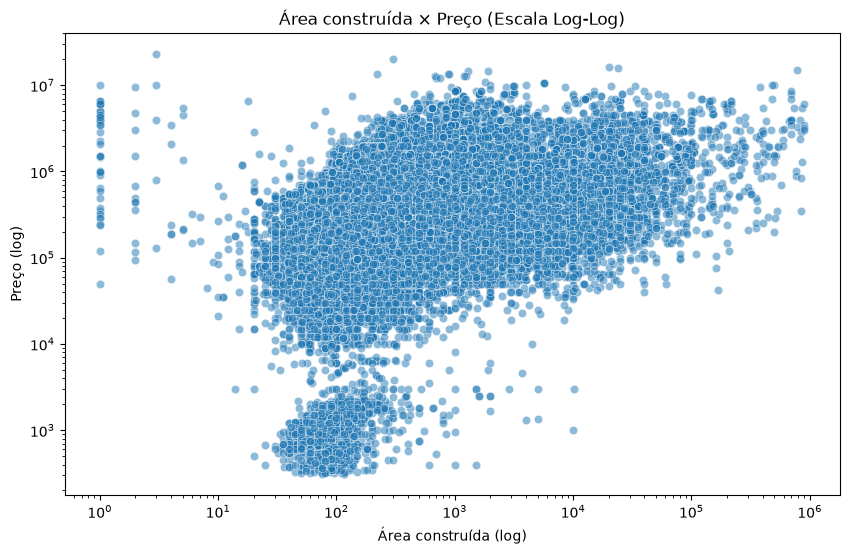

In [87]:
#scatter plot para visualizar a relação entre o preço e a área do imóvel
plt.figure(figsize=(10,6))

sns.scatterplot(
    data= df_tratado,
    x="m2_real",
    y="price",
    alpha=0.5
)

plt.xscale("log")
plt.yscale("log")

plt.title("Área construída × Preço (Escala Log-Log)")
plt.xlabel("Área construída (log)")
plt.ylabel("Preço (log)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/scatterplot_area_preco.png",
    dpi=300,
    bbox_inches="tight"
)


### Relação entre área construída e preço dos imóveis

A Figura acima apresenta a relação entre a área construída (`m2_useful`) e o preço dos imóveis (`price`), utilizando escala logarítmica em ambos os eixos (log-log). A transformação logarítmica permitiu distribuir melhor as observações ao longo do gráfico, reduzindo o efeito da grande amplitude dos valores presentes na base de dados e facilitando a visualização dos padrões existentes.

Observa-se uma tendência crescente entre as variáveis, indicando que imóveis com maior área construída tendem, em geral, a apresentar preços mais elevados. Entretanto, essa relação apresenta elevada dispersão, evidenciando que imóveis com áreas semelhantes podem possuir preços bastante distintos.

Essa variabilidade demonstra que o preço dos imóveis não depende exclusivamente da área construída, sendo influenciado também por outros fatores, como localização, número de quartos e banheiros, características estruturais e aspectos socioeconômicos da região.

Também foram identificados alguns pontos isolados (outliers), correspondentes a imóveis com áreas muito pequenas e preços elevados ou imóveis de grande área com preços relativamente baixos. Apesar da presença desses registros, a tendência geral permanece consistente, indicando uma associação positiva entre área construída e preço.

Os resultados observados neste gráfico corroboram a análise da matriz de correlação de Pearson mostrada a seguir, que identificou uma associação positiva entre essas variáveis, embora de intensidade limitada. Dessa forma, conclui-se que a área construída constitui um importante atributo explicativo do preço dos imóveis, mas não é suficiente, isoladamente, para representar toda a variabilidade observada na variável resposta.

#  Persistem alguns outliers

Ainda podem ser observados alguns imóveis com preços muito elevados e outros com preços muito baixos para determinada área.

Entretanto, eles representam uma pequena parcela da base e podem corresponder a:

imóveis de luxo;
imóveis em regiões extremamente valorizadas;
imóveis com características especiais.

Esses registros não precisam ser removidos automaticamente, principalmente porque modelos como Random Forest Regressor são naturalmente robustos à presença de outliers.

5. Um agrupamento merece investigação

Na parte inferior do gráfico existe um grupo de imóveis com preços entre aproximadamente 10³ e 10⁴ (1.000 a 10.000 unidades monetárias).

Esses preços são muito inferiores ao restante da distribuição e podem indicar:

erros de cadastro;
anúncios incompletos;
imóveis vendidos apenas pelo terreno;
registros inconsistentes.

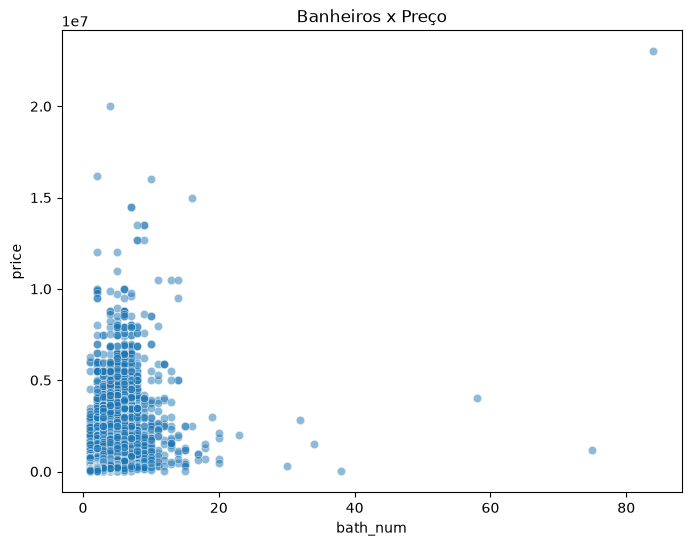

In [88]:
#Scatter plot para visualizar a relação entre o preço e o número de banheiros do imóvel
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_tratado,
    x="bath_num",
    y="price",
    alpha=0.5
)

plt.title("Banheiros x Preço")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/scatterplot_banheiros_preco.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Análise do gráfico

1. Existe uma tendência positiva

Observa-se que, em geral, imóveis com maior número de banheiros tendem a apresentar preços mais elevados. Isso confirma que a variável bath_num possui relação com a variável-alvo (price), o que está de acordo com a matriz de correlação obtida anteriormente (≈ 0,54), sendo uma das variáveis numéricas mais relevantes para a previsão do preço.

2. Grande concentração entre 1 e 8 banheiros

A maior parte dos imóveis possui entre 1 e 8 banheiros, faixa considerada compatível com o mercado imobiliário.

Também é nessa região que se concentram praticamente todos os imóveis da base.

3. Presença de valores extremos

O gráfico mostra alguns imóveis com:

aproximadamente 18 banheiros;
30 banheiros;
34 banheiros;
57 banheiros;
75 banheiros.

Esses valores são extremamente incomuns para imóveis residenciais e podem representar:

erros de digitação;
imóveis comerciais;
hotéis;
edifícios inteiros anunciados como um único imóvel;
registros inconsistentes.

. Grande dispersão dos preços

Mesmo imóveis com o mesmo número de banheiros apresentam preços bastante diferentes.

Por exemplo:

imóveis com 4 banheiros possuem preços desde algumas centenas de milhares até vários milhões.

Isso mostra que:

número de banheiros influencia o preço;
mas não é suficiente para explicá-lo sozinho.

Outras variáveis, como localização, área construída, padrão construtivo, idade do imóvel e infraestrutura da região, também exercem forte influência.

5. Outliers de preço

Também existem alguns imóveis extremamente caros (acima de 15 ou 20 milhões), independentemente da quantidade de banheiros.

Esses registros provavelmente representam imóveis de luxo e não necessariamente erros de cadastro.

## Relação entre Número de Banheiros e Preço

A Figura apresenta a relação entre o número de banheiros (`bath_num`) e o preço (`price`) dos imóveis. Observa-se uma tendência positiva, indicando que imóveis com maior quantidade de banheiros tendem a apresentar preços mais elevados.

A maior parte dos imóveis concentra-se entre 1 e 8 banheiros, faixa considerada compatível com o mercado residencial. Nessa região também se observa a maior concentração de preços, evidenciando que essa é a característica predominante do conjunto de dados.

Apesar da tendência crescente, existe elevada dispersão dos preços para imóveis com o mesmo número de banheiros. Esse comportamento demonstra que essa variável, embora importante, não explica isoladamente o valor do imóvel. Outros fatores, como área construída, localização, estado de conservação, vagas de garagem e características da região, também influenciam significativamente o preço final.

O gráfico também evidencia alguns registros com quantidade muito elevada de banheiros (superior a 15), considerados valores atípicos para imóveis residenciais. Esses casos devem ser analisados individualmente para verificar se representam imóveis de características especiais, empreendimentos comerciais ou possíveis inconsistências na base de dados.

De forma geral, a análise confirma que a variável `bath_num` apresenta associação positiva com a variável-alvo `price`, justificando sua utilização como uma importante variável explicativa nos modelos de regressão desenvolvidos neste projeto.

In [89]:
#Verificando quantidade de banheiros
df_tratado["bath_num"].value_counts().sort_index().tail(20)

bath_num
9.0     66
10.0    44
11.0    23
12.0    15
13.0    17
14.0    10
15.0    10
16.0     2
17.0     3
18.0     3
19.0     1
20.0     4
23.0     1
30.0     1
32.0     1
34.0     1
38.0     1
58.0     1
75.0     1
84.0     1
Name: count, dtype: int64

In [90]:
#Verificando número de banheiros
df_tratado.nlargest(20,"bath_num")[
    ["bath_num","room_num","m2_useful","price"]
]

,bath_num,room_num,m2_useful,price
15496,84.0,84.0,92.0,23000000.0
90909,75.0,73.0,92.0,1200000.0
86879,58.0,58.0,92.0,4000000.0
3680,38.0,35.0,2000.0,5000.0
2791,34.0,30.0,2000.0,1500000.0
31470,32.0,32.0,92.0,2800000.0
65628,30.0,30.0,92.0,300000.0
31431,23.0,23.0,550.0,2000000.0
13385,20.0,36.0,92.0,1850000.0
19856,20.0,16.0,517.0,680000.0


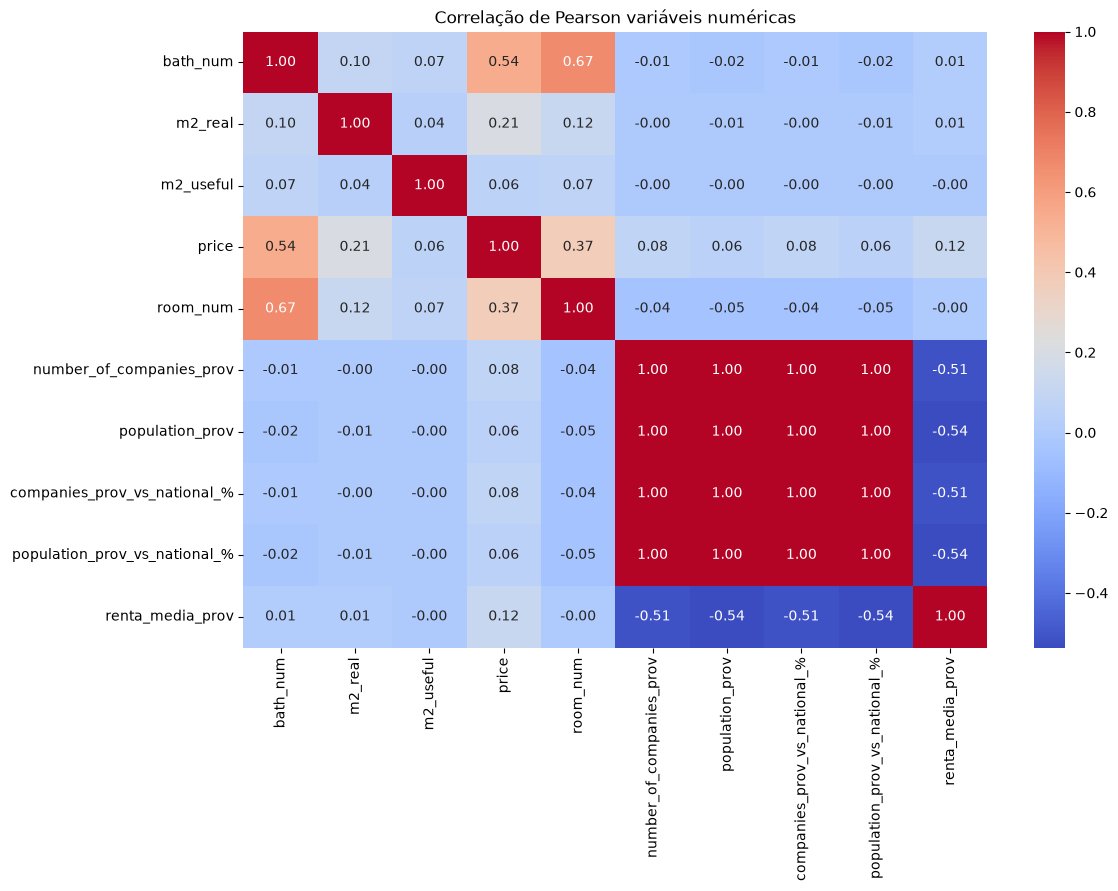

In [91]:
#correlation matrix
numericas = df_tratado.select_dtypes(include=np.number)
correlacao = numericas.corr()
plt.figure(figsize=(12,8))

sns.heatmap(
    correlacao,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlação de Pearson variáveis numéricas")
# Salva o gráfico
plt.savefig(
    "../outputs/figures/correlacao_pearson_numéricas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Correlação entre as variáveis numéricas

A Figura apresenta o mapa de calor da matriz de correlação de Pearson entre as variáveis numéricas utilizadas na análise exploratória. O coeficiente de correlação de Pearson varia entre -1 e +1, sendo que valores próximos de +1 indicam forte correlação positiva, valores próximos de -1 representam forte correlação negativa e valores próximos de zero indicam ausência de relação linear significativa.

Em relação à variável-alvo (`price`), observou-se que `bath_num` apresentou a maior correlação positiva (0,54), indicando que imóveis com maior número de banheiros tendem a possuir preços mais elevados. O número de quartos (`room_num`) também apresentou correlação positiva moderada (0,37). Já as variáveis relacionadas à área (`m2_real` e `m2_useful`) exibiram correlações fracas com o preço (0,21 e 0,06, respectivamente), sugerindo que outros fatores além da área exercem influência importante sobre o valor dos imóveis.

Entre as variáveis explicativas, destacou-se a correlação de 0,67 entre `bath_num` e `room_num`, comportamento esperado em imóveis residenciais, uma vez que imóveis maiores normalmente possuem mais quartos e banheiros. Como esse coeficiente permanece abaixo dos valores normalmente associados à multicolinearidade severa (0,80 ou superior), não representa um problema significativo para a modelagem.

As variáveis socioeconômicas `number_of_companies_prov`, `population_prov`, `companies_prov_vs_national_%` e `population_prov_vs_national_%` apresentaram correlações extremamente elevadas, próximas de 1,00, indicando forte redundância de informação. Esse resultado caracteriza um caso de multicolinearidade entre essas variáveis. Apesar disso, optou-se por mantê-las durante a modelagem, uma vez que o algoritmo Random Forest é robusto à presença de variáveis altamente correlacionadas.

Por fim, a variável `renta_media_prov` apresentou correlação negativa moderada com os indicadores de população e número de empresas (entre -0,51 e -0,54), indicando uma tendência inversa entre essas características no conjunto de dados analisado.

In [92]:
#assimetria das variável preço
df_tratado["price"].skew()

np.float64(7.450226517897443)

A análise da variável-alvo (price) revelou coeficiente de assimetria igual a 7,45, caracterizando uma distribuição fortemente assimétrica à direita. Esse resultado indica que a maior parte dos imóveis apresenta preços relativamente baixos, enquanto uma pequena quantidade de imóveis de alto valor gera uma longa cauda na distribuição. 
Esse comportamento é comum em bases de dados do mercado imobiliário e justifica a aplicação da transformação logarítmica da variável resposta antes do treinamento dos modelos de regressão, reduzindo a influência dos valores extremos e favorecendo um melhor ajuste dos algoritmos.

In [93]:
#assimetria das variáveis numéricas
numericas.skew()

bath_num                           9.035410
m2_real                           30.240386
m2_useful                        218.906606
price                              7.450227
room_num                           6.545885
number_of_companies_prov           3.187009
population_prov                    3.102808
companies_prov_vs_national_%       3.186095
population_prov_vs_national_%      3.101539
renta_media_prov                  -1.169488
dtype: float64

As variáveis relacionadas à área (m2_real e m2_useful) apresentaram elevada assimetria positiva, refletindo a coexistência de imóveis de pequeno porte e propriedades de grandes dimensões na base de dados. A inspeção dos registros extremos mostrou que parte desses valores corresponde a imóveis efetivamente muito grandes, enquanto alguns casos isolados apresentaram medidas incomuns, características típicas de bases provenientes de anúncios imobiliários. Como essas observações representam uma parcela reduzida do conjunto de dados e o modelo Random Forest é relativamente robusto à presença de valores extremos, optou-se por mantê-las durante a modelagem. Em contrapartida, a variável preco_por_m2 foi utilizada apenas para fins exploratórios e excluída do conjunto de preditores por derivar diretamente da variável-alvo (price), evitando vazamento de informação (data leakage).

## Estatística Descritiva

O conjunto de dados apresenta aproximadamente 100 mil registros contendo informações sobre imóveis localizados na Espanha. As variáveis incluem características físicas dos imóveis, localização, infraestrutura e indicadores socioeconômicos das províncias. A análise dos tipos de dados mostrou a presença de variáveis numéricas, categóricas e booleanas, sendo necessária a conversão de algumas colunas originalmente importadas como texto.

Distribuição da variável alvo

O histograma da variável price revelou uma distribuição fortemente assimétrica à direita. A maioria dos imóveis encontra-se concentrada em faixas de preços menores, enquanto poucos imóveis apresentam preços extremamente elevados, caracterizando uma longa cauda de distribuição. Esse comportamento indica a presença de diversos outliers, característica comum em bases de dados imobiliárias.

Boxplot

O boxplot confirmou a existência de um grande número de valores extremos acima do terceiro quartil. Esses imóveis representam propriedades de alto padrão e influenciam significativamente a média dos preços. Dessa forma, a mediana torna-se uma medida de tendência central mais representativa do conjunto de dados.

Relação entre área e preço

O gráfico de dispersão entre m2_real e price indica uma tendência positiva, sugerindo que imóveis com maior área construída tendem a apresentar preços mais elevados. Entretanto, observa-se elevada dispersão dos pontos, indicando que outros fatores também influenciam significativamente o valor dos imóveis.

Relação entre banheiros e preço

Observou-se que imóveis com maior número de banheiros tendem a apresentar preços mais elevados, corroborando a correlação positiva observada na matriz de correlação.

Correlação

A matriz de correlação mostrou que a variável bath_num apresentou a maior correlação linear com o preço (≈0,54), seguida por m2_real (≈0,21). Em contrapartida, verificou-se correlação praticamente perfeita entre algumas variáveis socioeconômicas da província, indicando `multicolinearidade`. 

Obs:Essas variáveis deverão ser avaliadas durante a etapa de seleção de atributos para evitar redundância na modelagem, optei por deletá-las.

# Fase 2: Tratamento e Limpeza (Data Prep) Linhas Duplicadas:

 Localize e remova registros idênticos duplicados para eliminar redundâncias na amostragem; e/ou justifique no notebook sua decisão de remover ou manter cada tipo de duplicidade encontrada. Valores Ausentes (Missing Data): Identifique os valores ausentes e aplique uma estratégia de imputação adequada. É obrigatório registrar uma justificativa textual para a sua decisão: a substituição foi orientada pela Média (adequada para distribuições simétricas) ou pela Mediana (adequada para isolar a distorção causada por outliers)? Gerenciamento de Outliers: Detecte anomalias e valores discrepantes nas variáveis explicativas por meio de diagramas de caixa (boxplots). Adote uma postura embasada (remoção, contenção por limite ou manutenção), justificando o impacto dessa ação no modelo escolhido, ciente de que modelos como Regressão Linear são altamente sensíveis a outliers e podem ter seus coeficientes distorcidos por valores extremos.

In [10]:
#Criando uma cópia do dataset original para tratamento
df_tratado = df.copy()

In [11]:
#Verificando a presença de linhas duplicadas no dataset original
print("Linhas duplicadas:", df.duplicated().sum())

Linhas duplicadas: 168


In [12]:
#Vericando tipo de linhas duplicadas
df_tratado[df_tratado.duplicated()]

,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
4674,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
4996,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
5886,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
6304,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
6745,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97952,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
98116,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
99650,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,11632,174549,0.35,0.37,NaN
99660,Pegando a eroski.,Anuncio actualizado el 10 de abril,0,1,2,1,0,segunda mano/buen estado,2002,no indicado,...,3,1,0,1,NaN,11632,174549,0.35,0.37,NaN


Esse resultado mostra que o problema é maior do que apenas converter price. O CSV contém muitos registros inválidos, sendo a maioria deles cabeçalhos repetidos.

In [13]:
#Remove linhas duplicadas do dataset tratado
df_tratado.drop_duplicates(inplace=True)

In [14]:
#verificando a presença de linhas duplicadas após exclusão das mesmas 
df_tratado.reset_index(drop=True, inplace=True)
print("Linhas duplicadas:", df_tratado.duplicated().sum())

Linhas duplicadas: 0


## Observação:

Foram removidos os registros completamente duplicados, pois representam redundância na base de dados e poderiam introduzir viés nas análises estatísticas e nos modelos de aprendizado de máquina.

In [15]:
#valores ausentes por coluna no dataset tratado
df_tratado.isnull().sum().sort_values(ascending=False)

ground_size                      99816
unfurnished                      99353
kitchen                          97787
loc_street                       85685
heating                          74285
construct_date                   67941
orientation                      60584
garage                           59189
loc_neigh                        56310
m2_useful                        47156
lift                             41035
renta_media_prov                 40631
energetic_certif                 25309
floor                            20307
condition                        13941
loc_district                     13747
ad_description                    4574
price                                0
population_prov_vs_national_%        0
companies_prov_vs_national_%         0
population_prov                      0
number_of_companies_prov             0
air_conditioner                      0
terrace                              0
swimming_pool                        0
storage_room             

In [16]:
#Tratando variavel alvo price
df_tratado["price"] = (
    df_tratado["price"]
      .astype(str)
      .str.replace("€", "", regex=False)
      .str.replace(".", "", regex=False)   # separador de milhar
      .str.replace(",", ".", regex=False)  # separador decimal, se houver
      .str.strip()
)

df_tratado["price"] = pd.to_numeric(df_tratado["price"], errors="coerce")

In [18]:
df_tratado["price"].info()

<class 'pandas.Series'>
RangeIndex: 99832 entries, 0 to 99831
Series name: price
Non-Null Count  Dtype  
--------------  -----  
99816 non-null  float64
dtypes: float64(1)
memory usage: 780.1 KB


In [17]:
#verificando valores de preço
df_tratado.loc[df_tratado["price"].isna()]

,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
4248,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,26743,388786,0.80,0.83,NaN
9432,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,138964,1838819,4.16,3.94,21.613
11193,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,96638,1128908,2.90,2.42,NaN
60085,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,30588,499100,0.92,1.07,NaN
61756,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,83313,1119351,2.50,2.40,22.803
70378,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,49582,720592,1.49,1.54,21714.000
78266,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,62984,761947,1.89,1.63,NaN
79942,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,24668,519932,0.74,1.11,NaN
80447,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,538917,6578079,16.15,14.08,29.400
86032,ad_description,ad_last_update,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,construct_date,energetic_certif,...,room_num,storage_room,swimming_pool,terrace,unfurnished,70373,1018510,2.11,2.18,22.339


Observação:  ainda constam 16 valores a serem tratados  A conversão para valores numéricos eliminou a maior parte dos registros inválidos e sobraram apenas 16 linhas problemáticas.

Essas 16 linhas são claramente cabeçalhos repetidos inseridos no meio do arquivo. Observe que todas possuem exatamente os nomes das colunas como valores:

Índice	ad_description	ad_last_update	air_conditioner	...
4248	ad_description	ad_last_update	air_conditioner	...
9432	ad_description	ad_last_update	air_conditioner	...

 

In [18]:
#Verifica quantas linhas da coluna price possuem exatamente o texto "price".
(df_tratado["price"] == "price").sum()

np.int64(0)

In [19]:
#Pesquisar novamente valores nulos
print(df_tratado.isnull().sum())

ad_description                    4574
ad_last_update                       0
air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
construct_date                   67941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
ground_size                      99816
heating                          74285
house_id                             0
house_type                           0
kitchen                          97787
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_neigh                        56310
loc_street                       85685
loc_zone                             0
m2_real                  

In [20]:
#Verifica as linhas onde a coluna "price" possui valores nulos
df_tratado.loc[df_tratado["price"].isna(), ["price", "m2_real", "bath_num"]]

,price,m2_real,bath_num
4248,NaN,m2_real,bath_num
9432,NaN,m2_real,bath_num
11193,NaN,m2_real,bath_num
60085,NaN,m2_real,bath_num
61756,NaN,m2_real,bath_num
70378,NaN,m2_real,bath_num
78266,NaN,m2_real,bath_num
79942,NaN,m2_real,bath_num
80447,NaN,m2_real,bath_num
86032,NaN,m2_real,bath_num


## Observação:
O texto "price" foi convertido para NaN, revelando essas linhas inválidas. Como apenas 16 delas permaneceram após os tratamentos anteriores, são essas que você está vendo agora.



In [ ]:
#executando limpeza
df = df.dropna(subset=["price"]).reset_index(drop=True)
df = df[df["m2_real"] != "m2_real"].reset_index(drop=True)
df = df[df["m2_real"] != "m2_real"].reset_index(drop=True)

In [26]:
#removendo linhas com valores nulos na coluna "price" e "m2_real"
df_tratado = df_tratado.dropna(subset=["price", "m2_real"])


In [27]:
#verificando se ainda constam cabeçalhos repetidos
cabecalho = (
    df_tratado.astype(str) ==
    pd.Series(df_tratado.columns, index=df_tratado.columns)
).all(axis=1)

print("Cabeçalhos repetidos:", cabecalho.sum())

Cabeçalhos repetidos: 0


In [28]:
#Conferindo se ainda existem valores nulos na coluna "price" após a remoção
df_tratado.loc[df_tratado["price"].isna(), ["price", "m2_real", "bath_num"]]

,price,m2_real,bath_num


In [29]:
#Conferindo se ainda existem valores nulos na coluna "price" após a remoção
df_tratado["price"].isna().sum()

np.int64(0)

In [30]:
#pesquisando variáveis com valores nulos
print(df_tratado.isnull().sum())

ad_description                    4574
ad_last_update                       0
air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
construct_date                   67941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
ground_size                      99816
heating                          74285
house_id                             0
house_type                           0
kitchen                          97787
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_neigh                        56310
loc_street                       85685
loc_zone                             0
m2_real                  

2) Colunas para remover

Estas colunas normalmente não agregam valor para a análise ou para o modelo.

In [31]:
#pesquisando a porcentagem de variáveis com mais valores nulos
tabela_nulos = pd.DataFrame({
    "Valores Nulos": df_tratado.isnull().sum(),
    "Percentual (%)": (df_tratado.isnull().sum() / len(df_tratado) * 100).round(2)
}).sort_values("Percentual (%)", ascending=False)

tabela_nulos

,Valores Nulos,Percentual (%)
ground_size,99816,100.00
unfurnished,99353,99.54
kitchen,97787,97.97
loc_street,85685,85.84
heating,74285,74.42
construct_date,67941,68.07
orientation,60584,60.70
garage,59189,59.30
loc_neigh,56310,56.41
m2_useful,47156,47.24


## Remover as colunas com muitos valores ausentes

Essas colunas possuem mais de 55% de valores nulos e sua recuperação por imputação não seria confiável.

Coluna	% Nulos	Decisão
ground_size	100,00%	Remover
unfurnished	99,54%	Remover
kitchen	97,97%	Remover
loc_street	85,84%	Remover
heating	74,42%	Remover
construct_date	68,07%	Remover
orientation	60,70%	Remover
loc_neigh	56,41%	Remover

In [32]:
#Removendo colunas irrelevantes para a análise
colunas_remover = [
    "ground_size",
    "unfurnished",
    "kitchen",
    "loc_street",
    "heating",
    "construct_date",
    "orientation",
    #"garage",
    "loc_neigh"
]

df_tratado = df_tratado.drop(columns=colunas_remover)

In [33]:
#removendo colunas irrelevantes para a análise
colunas_remover = [
    "id",                # identificador
    "house_id",          # identificador único
    "url",               # link do anúncio
    "thumbnail",         # imagem
    "ad_description",    # texto livre
    "ad_last_update"     # data atualização site
]
df_tratado.drop(columns=colunas_remover,
        inplace=True,
        errors="ignore")

In [34]:
#m2real - dados ausentes imputados com a mediana e variável convertida para inteiro
df_tratado["m2_real"] = pd.to_numeric(
    df_tratado["m2_real"],
    errors="coerce"
)

df_tratado["m2_real"] = df_tratado["m2_real"].fillna(
    df_tratado["m2_real"].median()
)

In [35]:
#Conferindo tratamento da variável m2_real
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                        47156
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 


## m2_useful (47%)

Como existe a variável m2_real, faz sentido preencher com a mediana.

In [36]:
#m2_useful - imputando valores ausentes com a mediana e convertendo a variável para inteiro
df_tratado["m2_useful"] = pd.to_numeric(
    df_tratado["m2_useful"],
    errors="coerce"
)

df_tratado["m2_useful"] = df_tratado["m2_useful"].fillna(
    df_tratado["m2_useful"].median()
)

In [37]:
#Conferindo tratamento da variável m2_useful
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [39]:
#room_num - imputado valores ausentes com mediana e a variavel foi convertida para inteiro


df_tratado["room_num"] = pd.to_numeric(
    df_tratado["room_num"],
    errors="coerce"
)

df_tratado["room_num"] = df_tratado["room_num"].fillna(
    df_tratado["room_num"].median()
)

In [40]:
#Conferindo tratamento da variável room_num
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [41]:
#bathnum imputando valores ausentes com a mediana e convertendo variavel para inteiro
df_tratado["bath_num"] = pd.to_numeric(
    df_tratado["bath_num"],
    errors="coerce"
)

df_tratado["bath_num"] = df_tratado["bath_num"].fillna(
    df_tratado["bath_num"].median()
)

In [42]:
#Conferindo tratamento da variável bath_num
print(df_tratado.isnull().sum())

air_conditioner                      0
balcony                              0
bath_num                             0
built_in_wardrobe                    0
chimney                              0
condition                        13941
energetic_certif                 25309
floor                            20307
garage                           59189
garden                               0
house_type                           0
lift                             41035
loc_city                             0
loc_district                     13747
loc_full                             0
loc_zone                             0
m2_real                              0
m2_useful                            0
obtention_date                       0
price                                0
reduced_mobility                     0
room_num                             0
storage_room                         0
swimming_pool                        0
terrace                              0
number_of_companies_prov 

In [43]:
df_tratado["floor"].unique()

<StringArray>
[           '2 plantas',   'planta 2ª exterior',            '3 plantas',
   'planta 1ª exterior',                    nan,             '1 planta',
   'planta 3ª exterior',        'bajo exterior',            'planta 2ª',
   'planta 4ª exterior',            '4 plantas',            'planta 3ª',
            'planta 1ª',            '5 plantas',   'planta 5ª exterior',
   'planta 7ª exterior',             'exterior',   'planta 6ª exterior',
   'planta 2ª interior',            'planta 4ª',   'planta 4ª interior',
   'planta 9ª exterior',   'planta 7ª interior',   'planta 6ª interior',
   'planta 8ª interior',            'planta 6ª',            'planta 8ª',
   'planta 3ª interior',  'planta 10ª exterior',            'planta 5ª',
            'planta 7ª',                 'bajo',   'planta 8ª exterior',
 'entreplanta exterior',  'planta 13ª exterior',            'planta 9ª',
   'planta 5ª interior',        'bajo interior',   'planta 1ª interior',
  'planta 12ª exterior',  'planta 15ª

## Observação:
A variável floor será simplificada na fase 3 do projeto.

3) Colunas categóricas

Foram padronizadas  todas de uma vez e os valores ausentes preenchidos com "nao informado"

In [44]:
#Preenchendo valores nulos em variáveis categóricas com "nao informado"
categoricas = df_tratado.select_dtypes(include=["object","str"]).columns

for col in categoricas:
    df_tratado[col] = (
        df_tratado[col]
        .str.strip()
        .str.lower()
        .fillna("nao informado")
    )

In [45]:
print (categoricas)

Index(['air_conditioner', 'balcony', 'built_in_wardrobe', 'chimney',
       'condition', 'energetic_certif', 'floor', 'garage', 'garden',
       'house_type', 'lift', 'loc_city', 'loc_district', 'loc_full',
       'loc_zone', 'obtention_date', 'reduced_mobility', 'storage_room',
       'swimming_pool', 'terrace'],
      dtype='str')


In [46]:
#conferindo valores da variável  condition
df_tratado["condition"].value_counts(dropna=False)

condition
segunda mano/buen estado      72271
nao informado                 13941
segunda mano/para reformar    11045
promoción de obra nueva        2559
Name: count, dtype: int64

## Justificativa

Para as variáveis categóricas foi utilizada a moda (ou a categoria "Não informado"), preservando o maior número possível de registros e evitando a exclusão de observações potencialmente relevantes.

In [47]:
df_tratado["garage"].unique()

<StringArray>
[     'plaza de garaje incluida en el precio',
                              'nao informado',
 'plaza de garaje por 15.000 eur adicionales',
 'plaza de garaje por 12.500 eur adicionales',
 'plaza de garaje por 23.000 eur adicionales',
      'plaza de garaje por 1 eur adicionales',
 'plaza de garaje por 12.000 eur adicionales',
 'plaza de garaje por 13.000 eur adicionales',
 'plaza de garaje por 29.000 eur adicionales',
     'plaza de garaje por 40 eur adicionales',
 ...
 'plaza de garaje por 11.000 eur adicionales',
  'plaza de garaje por 5.900 eur adicionales',
      'plaza de garaje por 8 eur adicionales',
  'plaza de garaje por 8.400 eur adicionales',
  'plaza de garaje por 7.300 eur adicionales',
  'plaza de garaje por 8.500 eur adicionales',
  'plaza de garaje por 5.800 eur adicionales',
  'plaza de garaje por 7.500 eur adicionales',
 'plaza de garaje por 45 eur/mes adicionales',
 'plaza de garaje por 39.000 eur adicionales']
Length: 164, dtype: str

## Observação:

A variável garage será simplificada na fase 3 do projeto.

In [48]:
#Verificando se existem variáveis a serem tratadas
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99831
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   air_conditioner                99816 non-null  str    
 1   balcony                        99816 non-null  str    
 2   bath_num                       99816 non-null  float64
 3   built_in_wardrobe              99816 non-null  str    
 4   chimney                        99816 non-null  str    
 5   condition                      99816 non-null  str    
 6   energetic_certif               99816 non-null  str    
 7   floor                          99816 non-null  str    
 8   garage                         99816 non-null  str    
 9   garden                         99816 non-null  str    
 10  house_type                     99816 non-null  str    
 11  lift                           99816 non-null  str    
 12  loc_city                       99816 non-null  str    
 13  lo

In [49]:
#tratamento da variável renta_media_prov com a mediana da coluna, preenchendo valores nulos
df_tratado["renta_media_prov"] = df_tratado["renta_media_prov"].fillna(
    df_tratado["renta_media_prov"].median()
)

In [50]:
#conferindo se ainda existem valores nulos na coluna "renta_media_prov" após o preenchimento
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99831
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   air_conditioner                99816 non-null  str    
 1   balcony                        99816 non-null  str    
 2   bath_num                       99816 non-null  float64
 3   built_in_wardrobe              99816 non-null  str    
 4   chimney                        99816 non-null  str    
 5   condition                      99816 non-null  str    
 6   energetic_certif               99816 non-null  str    
 7   floor                          99816 non-null  str    
 8   garage                         99816 non-null  str    
 9   garden                         99816 non-null  str    
 10  house_type                     99816 non-null  str    
 11  lift                           99816 non-null  str    
 12  loc_city                       99816 non-null  str    
 13  lo

In [51]:
#Convertendo colunas de datas para o tipo datetime
datas = [
    #"construct_date",
    "obtention_date"
]

for c in datas:
    df_tratado[c] = pd.to_datetime(
        df_tratado[c],
        errors="coerce"
    )

In [52]:
#Conferindo se ainda existem valores nulos nas colunas de datas após a conversão
df_tratado.info()

<class 'pandas.DataFrame'>
Index: 99816 entries, 0 to 99831
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   air_conditioner                99816 non-null  str           
 1   balcony                        99816 non-null  str           
 2   bath_num                       99816 non-null  float64       
 3   built_in_wardrobe              99816 non-null  str           
 4   chimney                        99816 non-null  str           
 5   condition                      99816 non-null  str           
 6   energetic_certif               99816 non-null  str           
 7   floor                          99816 non-null  str           
 8   garage                         99816 non-null  str           
 9   garden                         99816 non-null  str           
 10  house_type                     99816 non-null  str           
 11  lift                           

In [53]:
#Verificando porcentagem de valores nulos
(df_tratado.isnull().mean() * 100).sort_values(ascending=False)

air_conditioner                  0.0
balcony                          0.0
population_prov_vs_national_%    0.0
companies_prov_vs_national_%     0.0
population_prov                  0.0
number_of_companies_prov         0.0
terrace                          0.0
swimming_pool                    0.0
storage_room                     0.0
room_num                         0.0
reduced_mobility                 0.0
price                            0.0
obtention_date                   0.0
m2_useful                        0.0
m2_real                          0.0
loc_zone                         0.0
loc_full                         0.0
loc_district                     0.0
loc_city                         0.0
lift                             0.0
house_type                       0.0
garden                           0.0
garage                           0.0
floor                            0.0
energetic_certif                 0.0
condition                        0.0
chimney                          0.0
b

## Tratamento de Valores Ausentes com a Mediana

Durante a etapa de preparação dos dados, algumas variáveis numéricas apresentavam valores ausentes (`NaN`). Para evitar a perda de registros e preservar a distribuição original dos dados, esses valores foram substituídos pela **mediana** de cada variável.

A mediana foi escolhida em vez da média porque é uma medida de tendência central menos sensível a valores extremos (outliers), característica bastante comum em bases de dados imobiliárias.

### Variáveis preenchidas com a mediana

#### `bath_num`
Representa o número de banheiros do imóvel.

Como existem imóveis com um número muito elevado de banheiros, a distribuição não é perfeitamente simétrica. Dessa forma, a mediana fornece uma estimativa mais representativa do valor típico da base.

---

#### `room_num`
Representa o número de quartos.

Assim como ocorre com os banheiros, existem imóveis muito grandes que elevam a média da variável. A utilização da mediana reduz a influência desses casos extremos.

---

#### `m2_real`
Representa a área construída (em metros quadrados).

Imóveis de luxo podem possuir áreas muito superiores à maioria dos registros, tornando a distribuição bastante assimétrica. A mediana preserva melhor o comportamento da maior parte dos imóveis.

---
---

#### `renta_media_prov`
Representa a renda média da província.

Como a renda também apresenta distribuição assimétrica entre diferentes regiões da Espanha, a mediana foi utilizada para representar um valor central mais robusto.

---

## Justificativa da utilização da mediana

A utilização da mediana apresenta diversas vantagens neste projeto:

- reduz a influência de valores extremos;
- preserva melhor a distribuição original dos dados;
- evita a exclusão de observações importantes;
- melhora a estabilidade dos modelos de Machine Learning;
- é especialmente indicada para variáveis numéricas com distribuição assimétrica.

Esse procedimento contribuiu para a construção de um conjunto de dados mais consistente, reduzindo o impacto dos valores ausentes durante o treinamento dos modelos de regressão.

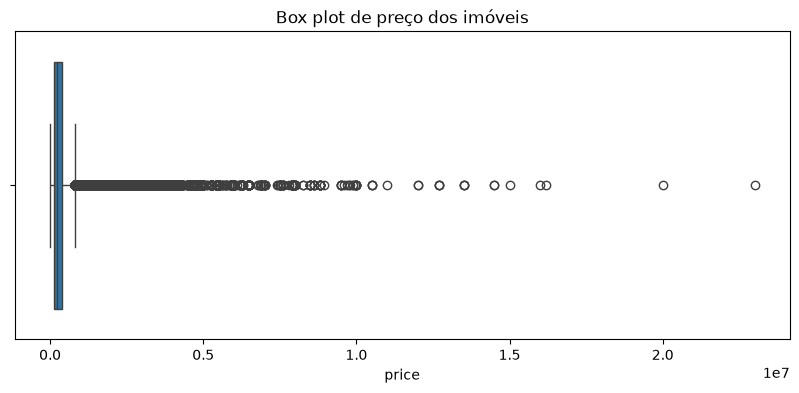

In [71]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado["price"])

plt.title("Box plot de preço dos imóveis")

plt.show()

# Análise de outliers

O boxplot da variável price evidencia uma distribuição fortemente assimétrica à direita, com grande concentração de imóveis de menor valor e diversos outliers acima do limite superior definido pelo método do IQR. Os valores extremos ultrapassam aproximadamente 650 mil, chegando a mais de 20 milhões. Esses registros podem representar imóveis de alto padrão e não necessariamente erros de cadastro. Como a Regressão Linear é sensível a valores extremos, optou-se por investigar os outliers antes de removê-los e utilizar a transformação logarítmica da variável price, reduzindo a assimetria da distribuição e a influência desses valores sobre o modelo.

In [54]:
#Verificando imóveis com valor = 0 na coluna "price" após o tratamento
(df_tratado["price"] == 0).sum()

np.int64(0)

In [55]:
# Procurando por valores inconsistentes
df_tratado.nsmallest(
    50,
    "price"
)[["price","m2_useful","room_num","bath_num"]]

,price,m2_useful,room_num,bath_num
11290,1.0,187.0,4.0,3.0
30691,1.0,80.0,3.0,2.0
97857,200.0,80.0,2.0,1.0
97936,220.0,65.0,3.0,1.0
92249,250.0,92.0,4.0,1.0
97827,250.0,99.0,3.0,2.0
97934,250.0,92.0,2.0,1.0
97841,275.0,50.0,2.0,1.0
97794,280.0,92.0,3.0,1.0
97796,280.0,55.0,1.0,1.0


Foram identificados registros com preços extremamente baixos (por exemplo, 1 €, 200 € e 300 €), incompatíveis com imóveis residenciais e decorrentes, provavelmente, de erros de cadastro, anúncios incompletos ou valores simbólicos utilizados pelos anunciantes. Esses registros foram considerados outliers de qualidade dos dados e removidos antes da modelagem para evitar distorções no treinamento dos modelos de regressão.

In [ ]:
#filtrand preços iguais ou superiores a 310 euros
df_tratado = df_tratado[
    df_tratado["price"] >= 310
].copy()

In [59]:
#verificando valores abaixo de 1000 euros
df_tratado.loc[
    df_tratado["price"] < 1000,
    ["price", "house_type"]
].value_counts()

price  house_type                
900.0  alquiler de piso              154
850.0  alquiler de piso              120
800.0  alquiler de piso              119
750.0  alquiler de piso              113
950.0  alquiler de piso               97
                                    ... 
450.0  alquiler de chalet pareado      1
525.0  alquiler de chalet adosado      1
310.0  alquiler de ático               1
595.0  alquiler de chalet adosado      1
570.0  alquiler de piso                1
Name: count, Length: 198, dtype: int64

Observou-se a permanência de alguns registros com preços extremamente baixos (1 €, 200 €, 250 €, entre outros). Como o menor valor encontrado entre os imóveis para aluguel era de 310 €, concluiu-se que esses registros não correspondiam a anúncios de locação, mas sim a inconsistências da base de dados, como erros de preenchimento, preços simbólicos ou anúncios incompletos. Dessa forma, esses registros foram removidos para evitar distorções no treinamento dos modelos de regressão.

In [60]:
#verificando valores de imoveis abaixo de 1000 euros
(df_tratado["price"] < 1000).sum()

np.int64(1417)

In [61]:
#Verificando valores de imóveis com preços baixos
df_tratado[df_tratado["price"] < 1000][[
    "price",
    "m2_useful",
    "room_num",
    "bath_num",
    "house_type"
]].head(30)

,price,m2_useful,room_num,bath_num,house_type
3627,750.0,90.0,3.0,1.0,alquiler de piso
3628,750.0,80.0,3.0,1.0,alquiler de piso
3631,700.0,92.0,2.0,1.0,alquiler de piso
3632,550.0,92.0,3.0,1.0,alquiler de piso
3634,650.0,41.0,1.0,1.0,alquiler de piso
3635,800.0,92.0,2.0,2.0,alquiler de piso
3636,650.0,92.0,3.0,2.0,alquiler de piso
3638,840.0,68.0,2.0,2.0,alquiler de dúplex
3639,750.0,92.0,3.0,2.0,alquiler de piso
3640,800.0,210.0,4.0,5.0,alquiler de chalet adosado


In [80]:
#Verificando variável house_type
df_tratado["house_type"].value_counts()

house_type
piso                                       53962
casa o chalet independiente                13592
casa o chalet                               6867
chalet adosado                              6441
ático                                       3345
casa de pueblo                              3001
dúplex                                      2577
chalet pareado                              2482
finca rústica                               2276
alquiler de piso                            2222
casa rural                                  1564
estudio                                      692
caserón                                      161
alquiler de ático                            101
masía                                        100
alquiler de dúplex                            72
casa terrera                                  69
alquiler de casa o chalet independiente       56
alquiler de chalet adosado                    50
cortijo                                       30
alquiler 

Durante a etapa de pré-processamento dos dados, foi identificada a presença de registros referentes a imóveis destinados ao aluguel, representados por categorias da variável house_type iniciadas pelo termo "alquiler" (por exemplo, alquiler de piso, alquiler de casa o chalet e alquiler de estudio). Como o objetivo deste projeto é construir um modelo capaz de prever o preço de venda dos imóveis, esses registros foram removidos da base de dados.

A manutenção de imóveis para aluguel no conjunto de dados poderia introduzir inconsistências na modelagem, uma vez que os fatores que determinam o valor de locação são diferentes daqueles que influenciam o preço de venda. Misturar esses dois tipos de mercado faria com que o modelo aprendesse padrões distintos para a mesma variável-alvo, aumentando a variabilidade dos dados e reduzindo a capacidade de generalização.

In [62]:
df_tratado_sem_alquiler = df_tratado[
    ~df_tratado["house_type"]
        .fillna("")
        .str.strip()
        .str.lower()
        .str.startswith("alquiler")
].copy()

In [63]:
#conferindo remoção 
df_tratado_sem_alquiler["house_type"].str.startswith("alquiler").sum()

np.int64(0)

In [64]:
#conferindo novamenentte remoção do tipo alquiler da variável house_type
print(
    df_tratado_sem_alquiler["house_type"]
    .str.contains("alquiler", case=False, na=False)
    .sum()
)

0


In [65]:
#Verificando se ainda existem dados do tipo alquiler
print(df_tratado_sem_alquiler["house_type"].unique())

<StringArray>
['casa o chalet independiente',                       'ático',
              'casa de pueblo',                        'piso',
                  'casa rural',              'chalet adosado',
               'casa o chalet',                     'caserón',
              'chalet pareado',                      'dúplex',
                     'estudio',               'finca rústica',
                     'palacio',                       'torre',
                    'castillo',                       'masía',
                     'cortijo',                'casa terrera']
Length: 18, dtype: str


In [66]:
#Conferindo o shape do dataset após a remoção dos registros com house_type iniciando com "alquiler"
print(df_tratado_sem_alquiler.shape)
print(df_tratado_sem_alquiler["house_type"].value_counts())

(97203, 30)
house_type
piso                           53962
casa o chalet independiente    13592
casa o chalet                   6867
chalet adosado                  6441
ático                           3345
casa de pueblo                  3001
dúplex                          2577
chalet pareado                  2482
finca rústica                   2276
casa rural                      1564
estudio                          692
caserón                          161
masía                            100
casa terrera                      69
cortijo                           30
palacio                           18
torre                             18
castillo                           8
Name: count, dtype: int64


In [68]:
df_tratado_sem_alquiler[
    df_tratado_sem_alquiler["price"] < 1000
].sort_values("price")

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov


In [90]:
#verificando dataset
df_tratado_sem_alquiler.info()

<class 'pandas.DataFrame'>
Index: 97203 entries, 0 to 99831
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   air_conditioner                97203 non-null  str           
 1   balcony                        97203 non-null  str           
 2   bath_num                       97203 non-null  float64       
 3   built_in_wardrobe              97203 non-null  str           
 4   chimney                        97203 non-null  str           
 5   condition                      97203 non-null  str           
 6   energetic_certif               97203 non-null  str           
 7   floor                          97203 non-null  str           
 8   garage                         97203 non-null  str           
 9   garden                         97203 non-null  str           
 10  house_type                     97203 non-null  str           
 11  lift                           

## Remoção de alugueis, mantendo somente imóveis a venda.

Durante a análise exploratória identificou-se que a base de dados continha anúncios de venda e de aluguel, diferenciados pela variável house_type. Como os preços de aluguel e de venda representam mercados distintos e apresentam escalas de valores significativamente diferentes, optou-se por remover todos os anúncios de aluguel antes da etapa de modelagem. Essa filtragem reduziu a heterogeneidade da variável resposta e tornou o conjunto de dados mais consistente para a construção de modelos destinados à predição do preço de venda dos imóveis.

In [69]:
# Conferindo o shape do dataset após a remoção dos registros com house_type iniciando com "alquiler" e verificado ainda registros de preço igual a 1, que não fazem sentido para o modelo de previsão de preços de imóveis.
df_tratado_sem_alquiler[df_tratado_sem_alquiler["price"] == 1]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov


In [70]:
#Removendo variáveis com preço = 1
df_tratado2 = df_tratado_sem_alquiler[df_tratado_sem_alquiler["price"] > 310]

In [71]:
#conferindo remoção anterior
df_tratado2[df_tratado2["price"] == 1]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov


In [72]:
#verificando novamente se existem variáveis com tipo alquiler
df_tratado2["house_type"].str.startswith("alquiler").sum()

df_tratado2[
    df_tratado2["house_type"].str.contains("alquiler", case=False, na=False)
]["house_type"].value_counts()

Series([], Name: count, dtype: int64)

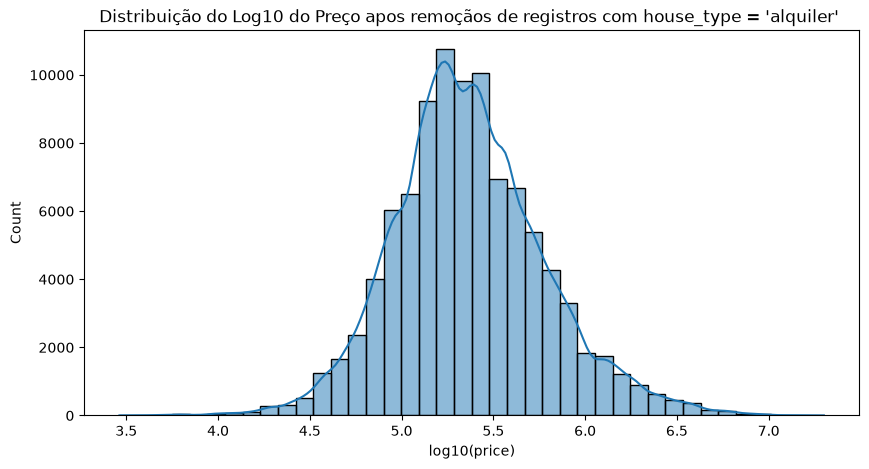

In [94]:
#Gráfico da variavel preço sem alquiler
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,5))

sns.histplot(
    np.log10(df_tratado2["price"]),
    bins=40,
    kde=True
)

plt.title("Distribuição do Log10 do Preço apos remoçãos de registros com house_type = 'alquiler' ")
plt.xlabel("log10(price)")


# Salva o gráfico
plt.savefig(
    "../outputs/figures/histograma_preco_log_sem_alquiler.png",
    dpi=300,
    bbox_inches="tight"
)


### Distribuição da variável `price` após o pré-processamento

A Figura apresenta a distribuição da variável `price` após a remoção dos anúncios de aluguel, eliminação de registros inconsistentes e aplicação da transformação logarítmica na base 10 (`log10(price)`).

Observa-se que a distribuição tornou-se aproximadamente unimodal e significativamente mais simétrica em comparação com a distribuição original. A maior concentração de observações encontra-se entre aproximadamente 5,0 e 5,6 na escala logarítmica, enquanto a curva de densidade acompanha de forma consistente o formato do histograma.

Em relação às análises anteriores, verifica-se o desaparecimento do agrupamento correspondente aos anúncios de aluguel, indicando que o conjunto de dados passou a representar exclusivamente o mercado de venda de imóveis. Além disso, a transformação logarítmica reduziu substancialmente a influência dos imóveis de maior valor, diminuindo a assimetria da variável resposta e tornando sua distribuição mais homogênea.

Apesar da permanência de uma discreta cauda à direita, característica comum em bases de dados imobiliárias, a distribuição obtida apresenta comportamento muito mais adequado para a etapa de modelagem preditiva, reduzindo o impacto dos valores extremos sem eliminar observações representativas do mercado.

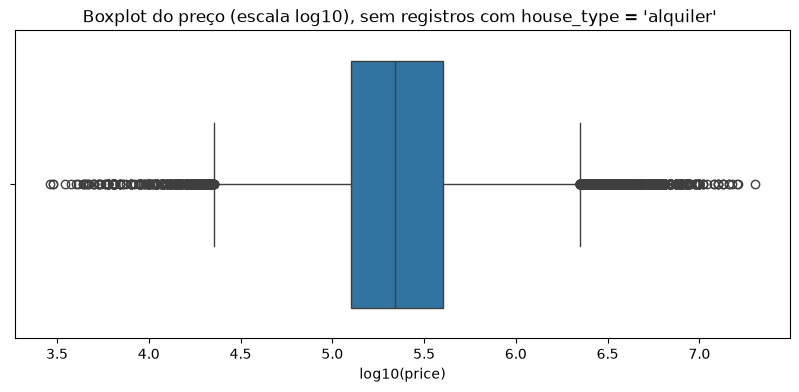

In [95]:
# Gráfico boxplot da variável preço sem alquiler
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,4))

sns.boxplot(x=np.log10(df_tratado2["price"]))

plt.title("Boxplot do preço (escala log10), sem registros com house_type = 'alquiler' ")
plt.xlabel("log10(price)")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_preco_log_sem_alquiler.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Boxplot da variável `price` após transformação logarítmica

A Figura apresenta o boxplot da variável `price` após a aplicação da transformação logarítmica na base 10 (`log10(price)`). Observa-se uma distribuição significativamente mais equilibrada quando comparada à escala original, evidenciando a redução da influência dos imóveis de maior valor sobre a distribuição dos dados.

A mediana encontra-se aproximadamente centralizada no intervalo interquartil (IQR), indicando maior simetria da distribuição após a transformação. Os limites dos bigodes abrangem a maior parte das observações, enquanto os pontos localizados além desses limites representam imóveis classificados como outliers segundo o critério de 1,5 vezes o IQR.

Embora ainda exista um número considerável de valores extremos, esse comportamento é esperado em bases de dados do mercado imobiliário, devido à coexistência de imóveis de diferentes padrões e faixas de preço. Após a transformação logarítmica, esses outliers passaram a exercer influência significativamente menor sobre a distribuição da variável resposta.

Em conjunto com o histograma da variável transformada, o boxplot confirma que a aplicação da transformação logarítmica tornou a distribuição dos preços mais homogênea e mais adequada para a etapa de modelagem preditiva.

In [73]:
#Comparação entre assimetrias do preço original e do preço transformado (log10):
print("Assimetria do preço original:")
print(df_tratado["price"].skew())

print("\nAssimetria do preço transformado:")
print(np.log10(df_tratado2["price"]).skew())   # ou price_log.skew()

Assimetria do preço original:
7.450226517897443

Assimetria do preço transformado:
0.3187142826859461


A variável-alvo `price` apresentou coeficiente de assimetria igual a 7,45, indicando forte assimetria positiva. Esse resultado demonstra que a maior parte dos imóveis concentra-se em faixas de preço inferiores, enquanto um número reduzido de imóveis de alto valor gera uma longa cauda na distribuição. Essa característica motivou a aplicação da transformação logarítmica da variável resposta (`price_log`), com o objetivo de reduzir a influência dos valores extremos e melhorar o desempenho dos modelos de regressão.

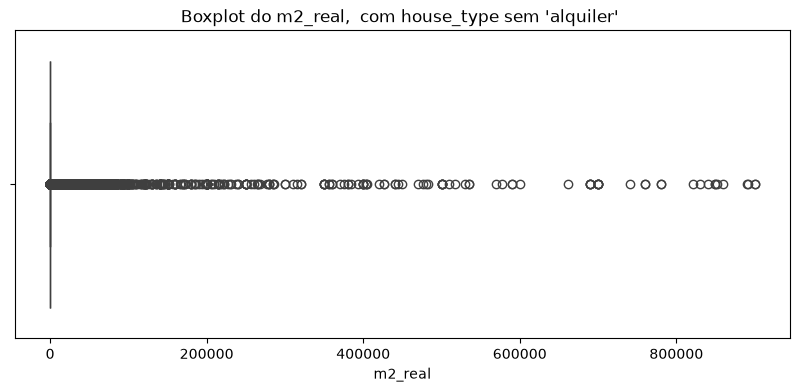

In [100]:
#Boxplot do m2_real,  com house_type sem 'alquiler

plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["m2_real"])

plt.title("Boxplot do m2_real,  com house_type sem 'alquiler' ")
plt.xlabel("m2_real")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_m2_real.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

## Análise do gráfico
O boxplot da variável m2_real evidencia que a distribuição da área construída também é fortemente assimétrica à direita, com uma grande quantidade de imóveis concentrados em áreas pequenas e médias e diversos valores extremamente elevados.

Análise do gráfico
A caixa do boxplot está comprimida próxima ao início da escala, indicando que a maior parte dos imóveis possui áreas relativamente pequenas.
O bigode superior termina muito antes do valor máximo observado, e a partir dele aparecem centenas de pontos isolados, classificados como outliers pelo método do IQR.
Existem imóveis com áreas superiores a 900.000 m², valor extremamente elevado para uma residência e que merece investigação.
Identificação dos outliers

Visualmente, os outliers começam aproximadamente entre 5.000 e 10.000 m² (o valor exato deve ser calculado pelo IQR). A partir desse ponto há imóveis com áreas cada vez maiores, chegando a aproximadamente:

100.000 m²
300.000 m²
500.000 m²
mais de 900.000 m²

Esses valores são muito superiores à área típica de imóveis residenciais.

Esses outliers podem ser erros?

Nem todos.

Alguns podem representar:

fazendas;
terrenos;
condomínios;
imóveis comerciais.

Entretanto, áreas como 300.000, 500.000 ou 900.000 m² são bastante incomuns para um dataset de imóveis residenciais e podem indicar:

erro de digitação;
unidade de medida incorreta;
área do terreno cadastrada no lugar da área construída;
registros inconsistentes.

Vale a pena investigar esses casos antes da modelagem.

In [101]:
df_tratado2.nlargest(
    20,
    "m2_real"
)[["m2_real", "m2_useful", "price", "house_type"]]

,m2_real,m2_useful,price,house_type
31039,900000,625.0,6000000.0,casa o chalet
89247,900000,92.0,3000000.0,casa o chalet independiente
32490,891800,1648.0,3182000.0,finca rústica
32406,890000,1613.0,3450000.0,casa rural
32353,860000,75.0,1300000.0,finca rústica
28988,851360,600.0,5500000.0,casa o chalet
12220,850000,92.0,2900000.0,finca rústica
35529,850000,355.0,350000.0,masía
31154,840000,780.0,840000.0,casa o chalet independiente
11846,830000,92.0,3950000.0,casa o chalet


In [74]:
# variável m2_useful apresentou aproximadamente 47% de valores ausentes na base original. Para permitir a utilização dessa informação durante a modelagem, os valores faltantes foram imputados pela mediana da variável, por ser uma medida robusta à presença de valores extremos. Entretanto, reconhece-se que a elevada proporção de dados ausentes pode reduzir a variabilidade dessa característica e limitar seu poder explicativo nos modelos preditivos.
df_tratado2.loc[
    df_tratado2["m2_useful"] > df_tratado2["m2_real"],
    ["m2_real", "m2_useful", "price", "house_type"]
].sample(20, random_state=42)

,m2_real,m2_useful,price,house_type
685,80,92.0,161000.0,piso
64546,100,208.0,160000.0,casa de pueblo
52132,80,92.0,248000.0,piso
9916,65,70.0,116000.0,chalet pareado
40362,50,92.0,134000.0,piso
85034,81,92.0,840000.0,piso
39611,170,400.0,570000.0,casa o chalet independiente
82591,60,92.0,305000.0,piso
46267,81,92.0,200000.0,piso
77061,82,92.0,229000.0,piso


Esses registros merecem investigação. O que chama a atenção não é o preço, mas sim o fato de m2_useful = 92 aparecer repetidamente em imóveis muito diferentes.

In [75]:
#Procurando registros com m2_useful igual a 92 no dataset atual
(df_tratado2["m2_useful"] == 92).sum()

np.int64(46509)

In [76]:
#Pesquisando registros com m2_useful igual a 92 no dataset original
(df["m2_useful"] == 92).sum()

np.int64(0)

In [77]:
#Pesquisando registros com m2_useful nulo no dataset original
df["m2_useful"].isna().sum()

np.int64(47156)

 ## Importante:
 
 variável m2_useful apresentou aproximadamente 47% de valores ausentes na base original. Para permitir a utilização dessa informação durante a modelagem, os valores faltantes foram imputados pela mediana da variável, por ser uma medida robusta à presença de valores extremos. Entretanto, reconhece-se que a elevada proporção de dados ausentes pode reduzir a variabilidade dessa característica e limitar seu poder explicativo nos modelos preditivos.

In [78]:
#Pesquisando registros com erros em m2_useful  no dataset tratado
df_tratado2.sort_values("m2_real", ascending=False)[
    ["m2_real", "price", "room_num", "bath_num", "house_type"]
].head(20)

,m2_real,price,room_num,bath_num,house_type
31039,900000,6000000.0,13.0,5.0,casa o chalet
89247,900000,3000000.0,9.0,8.0,casa o chalet independiente
32490,891800,3182000.0,3.0,2.0,finca rústica
32406,890000,3450000.0,6.0,2.0,casa rural
32353,860000,1300000.0,3.0,2.0,finca rústica
28988,851360,5500000.0,3.0,2.0,casa o chalet
35529,850000,350000.0,6.0,2.0,masía
12220,850000,2900000.0,6.0,3.0,finca rústica
31154,840000,840000.0,9.0,7.0,casa o chalet independiente
11846,830000,3950000.0,16.0,2.0,casa o chalet


A tabela acima mostra que  nem todos esses registros são erros. Muitos parecem representar propriedades rurais ou imóveis de luxo, o que justifica áreas muito grandes.

Análise dos maiores valores
Área (m²)	Tipo de imóvel	Avaliação
900.000	Casa/Chalé	Possível propriedade de luxo ou fazenda
900.000	Casa/Chalé	Possível
891.800	Finca rústica	Coerente
890.000	Casa rural	Coerente
860.000	Finca rústica	Coerente
851.360	Casa/Chalé	Pode ser propriedade rural
850.000	Finca rústica	Coerente
850.000	Masía	Coerente
840.000	Casa independente	Possível
830.000	Casa/Chalé	Possível
820.912	Finca rústica	Coerente
781.000	Finca rústica	Coerente
780.000	Castelo	Totalmente coerente
760.000	Masía	Coerente
741.425	Casa rural	Coerente....

A inspeção dos maiores valores da variável m2_real mostrou que os principais outliers correspondem, em sua maioria, a imóveis classificados como finca rústica, casa rural, masía e castillo. Esses tipos de imóveis normalmente abrangem grandes extensões de terreno, justificando áreas superiores a 700.000 m². Dessa forma, conclui-se que esses valores representam características reais do mercado imobiliário espanhol e não necessariamente erros de cadastro. Por esse motivo, optou-se por manter esses registros no conjunto de dados, uma vez que sua remoção poderia eliminar informações relevantes sobre imóveis de grande porte. Contudo, reconhece-se que esses valores extremos podem influenciar modelos sensíveis, como a Regressão Linear, sendo considerada a utilização de transformações logarítmicas e a avaliação de modelos mais robustos durante a etapa de modelagem.

Observação: É importante verificar a documentação do dataset para confirmar o significado de m2_real. Em muitos conjuntos de dados imobiliários, ela representa a área do imóvel (construída), mas em alguns casos pode representar a área total do terreno. Se for área do terreno, valores como 900.000 m² (90 hectares) são perfeitamente plausíveis para uma fazenda ou propriedade rural.


Esse resultado é muito significativo.

Você tem:

(m2_useful > m2_real).sum()

46509

Ou seja, 46.509 imóveis possuem área útil maior que a área total, o que é fisicamente impossível.

Isso representa aproximadamente metade da base (dependendo do tamanho final), indicando que não se trata de alguns outliers, mas sim de um problema sistemático na variável m2_useful.

O que isso significa?

Há fortes indícios de que ocorreu um problema na origem dos dados ou no processo de coleta (scraping). A variável m2_useful provavelmente:

foi preenchida incorretamente em muitos registros;
ou recebeu um valor padrão (como 92 m²) quando a informação estava ausente.

Portanto, m2_useful não é uma variável confiável.

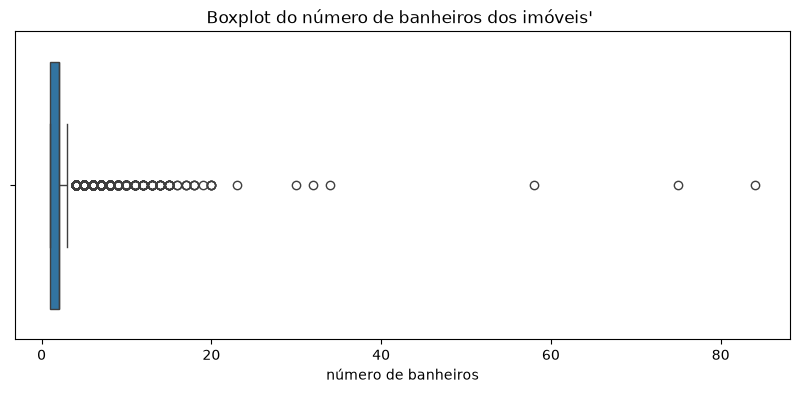

In [82]:
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["bath_num"])
plt.title("Boxplot do número de banheiros dos imóveis' ")
plt.xlabel("número de banheiros")

plt.show()

### Boxplot da variável `bath_num`

A Figura apresenta o boxplot da variável `bath_num`, correspondente ao número de banheiros dos imóveis. Observa-se que a maior parte das propriedades possui entre um e três banheiros, resultando em uma distribuição concentrada nas menores faixas da variável.

O boxplot identifica diversos valores classificados como outliers, principalmente acima de cinco banheiros. Entretanto, essa característica é esperada em variáveis discretas e assimétricas, nas quais o critério de 1,5 vezes o intervalo interquartil (IQR) tende a identificar como valores extremos observações relativamente incomuns, mas não necessariamente incorretas.

Durante a inspeção dos dados foram identificados alguns registros com quantidades excepcionalmente elevadas de banheiros (superiores a 30), associados, em alguns casos, a inconsistências entre o número de banheiros e a área útil do imóvel. Esses registros foram analisados individualmente durante a etapa de pré-processamento.

De modo geral, o gráfico confirma que a variável apresenta forte assimetria positiva, com predominância de imóveis contendo poucos banheiros e uma pequena quantidade de propriedades com valores muito superiores à média. Essa característica é compatível com a natureza do mercado imobiliário e foi considerada durante a construção dos modelos preditivos.

Impacto na modelagem

Como a variável bath_num apresentou uma correlação moderada com o preço (≈ 0,54), ela é uma variável importante para a previsão. Portanto, a remoção de outliers deve ser feita com cautela para evitar a perda de informações relevantes sobre imóveis de alto padrã

In [79]:
#procurando valores de número de banheiros discrepantes
df_tratado2[df_tratado2["bath_num"] > 10][
    ["bath_num", "room_num", "m2_real", "price", "house_type"]
].sort_values("bath_num", ascending=False)

,bath_num,room_num,m2_real,price,house_type
15496,84.0,84.0,3,23000000.0,palacio
90909,75.0,73.0,3095,1200000.0,casa o chalet independiente
86879,58.0,58.0,7763,4000000.0,caserón
2791,34.0,30.0,1900,1500000.0,caserón
31470,32.0,32.0,1458,2800000.0,casa o chalet independiente
...,...,...,...,...,...
10729,11.0,10.0,13200,3300000.0,casa o chalet independiente
31655,11.0,11.0,171845,2650000.0,casa o chalet
60057,11.0,16.0,1100,300000.0,casa rural
45300,11.0,17.0,594,860000.0,casa o chalet independiente


In [81]:
#Procurando registros inconsistentes de número de banheiros
df_tratado2[
    (df_tratado2["room_num"] > 30) &
    (df_tratado2["m2_real"] < 50)
]

,air_conditioner,balcony,bath_num,built_in_wardrobe,chimney,condition,energetic_certif,floor,garage,garden,...,reduced_mobility,room_num,storage_room,swimming_pool,terrace,number_of_companies_prov,population_prov,companies_prov_vs_national_%,population_prov_vs_national_%,renta_media_prov
15496,1,1,84.0,1,1,segunda mano/buen estado,en trámite,3 plantas,plaza de garaje incluida en el precio,1,...,0,84.0,1,1,1,96638,1128908,2.9,2.42,19818.0


Essa linha não parece ser um cabeçalho repetido. Ela revela outro problema de qualidade dos dados.

Veja os valores:

Variável	Valor	Esperado
bath_num	84.0	1, 2, 3, 4...
room_num	84.0	1, 2, 3, 4...
floor	3 plantas	OK
garage	plaza de garaje incluida en el precio	

In [82]:
#Removendo registro inconsistente 
df_tratado2 = df_tratado2.drop(index=[15496])

 A investigação dos outliers da variável bath_num mostrou que nem todos representam erros de cadastro. Diversos imóveis com elevado número de banheiros pertencem às categorias casarão, palácio e propriedades rurais, apresentando também grande área construída e elevado valor de mercado, o que justifica esses valores extremos. Entretanto, foram identificados registros claramente inconsistentes, como um imóvel com apenas 3 m², 84 quartos, 84 banheiros e preço de 23 milhões, indicando provável erro de cadastro. 
Apenas esses registros inconsistentes foram removidos, enquanto os demais outliers foram mantidos por representarem imóveis reais de grande porte. Essa abordagem preserva informações relevantes do mercado imobiliário sem introduzir distorções desnecessárias no modelo preditivo.

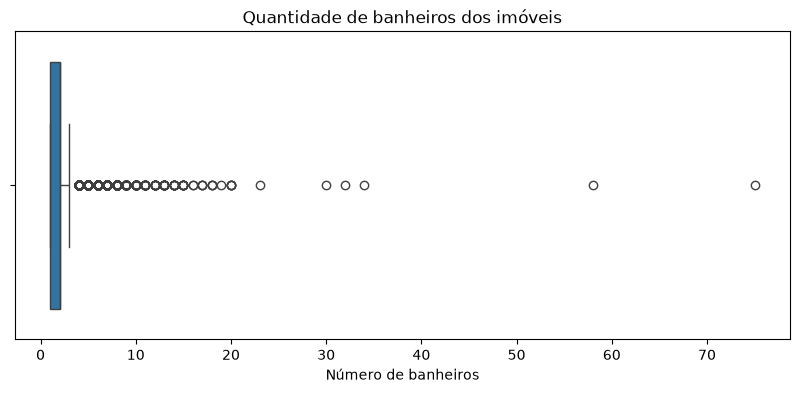

In [83]:
#Gráfico da quantidade de banheiros dos imóveis
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["bath_num"])
plt.title("Quantidade de banheiros dos imóveis")
plt.xlabel("Número de banheiros")

# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_quantidade_banheiros.png",
    dpi=300,
    bbox_inches="tight"
)
#plt.ylabel("Preço (log)")

plt.show()

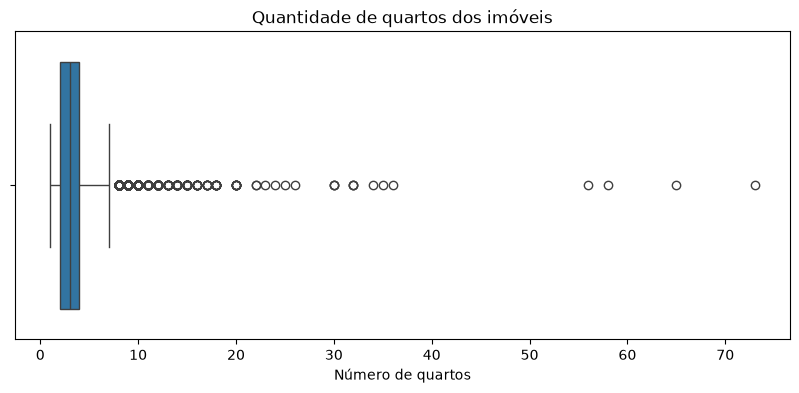

In [87]:
#Gráfico da quantidade de quartos dos imóveis
plt.figure(figsize=(10,4))

sns.boxplot(x=df_tratado2["room_num"])
plt.title("Quantidade de quartos dos imóveis")
plt.xlabel("Número de quartos")



# Salva o gráfico
plt.savefig(
    "../outputs/figures/boxplot_quantidade_quartos.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()



# Análise do gráfico de quartos

O boxplot da variável room_num evidencia que a maior parte dos imóveis possui entre 2 e 5 quartos, faixa representada pela região central da caixa (intervalo interquartil). A mediana encontra-se próxima de 3 ou 4 quartos, indicando que esse é o padrão predominante no conjunto de dados.

Observa-se uma quantidade considerável de outliers superiores, principalmente a partir de aproximadamente 8 quartos, estendendo-se até imóveis com mais de 70 quartos. Esses registros representam propriedades muito diferentes do padrão da base, como hotéis, palácios, casarões, castelos ou grandes propriedades rurais, e não refletem o perfil da maioria dos imóveis residenciais.

A presença desses valores extremos aumenta significativamente a dispersão da variável e pode influenciar modelos sensíveis, como a Regressão Linear, distorcendo seus coeficientes. Entretanto, esses registros podem representar imóveis reais e de alto padrão, não sendo necessariamente erros de cadastro.

Por esse motivo, a decisão de remover ou manter esses outliers deve considerar a natureza do problema. Caso o objetivo seja construir um modelo voltado ao mercado residencial comum, a remoção ou limitação desses valores extremos pode melhorar a capacidade de generalização do modelo. Por outro lado, se o objetivo for representar todo o mercado imobiliário, incluindo imóveis de luxo, esses registros devem ser preservados, podendo-se optar por técnicas menos sensíveis a outliers, como Random Forest Regressor, ou pela aplicação de transformações logarítmicas na variável alvo.

De forma geral, o gráfico confirma que a distribuição da variável room_num é fortemente assimétrica à direita, com predominância de imóveis contendo poucos quartos e uma pequena quantidade de propriedades extremamente grandes, caracterizando a existência de valores discrepantes (outliers) que devem ser considerados durante a etapa de preparação dos dados.

# Fase 2 – Tratamento e Limpeza dos Dados (Data Preparation)

## 1. Remoção de Linhas Duplicadas

Inicialmente, foi realizada uma verificação da existência de registros duplicados no conjunto de dados utilizando o método `duplicated()`. Foram identificadas linhas repetidas e registros contendo cabeçalhos inseridos incorretamente durante a coleta dos dados.

Os registros duplicados foram removidos para evitar que determinadas observações tivessem peso maior durante o treinamento dos modelos, reduzindo possíveis vieses e redundâncias na base de dados.

Além disso, foram removidas linhas contendo cabeçalhos repetidos no meio do arquivo, identificadas durante a conversão das colunas numéricas, pois esses registros não representavam imóveis válidos.

---

## 2. Tratamento de Valores Ausentes

Após a identificação dos valores ausentes utilizando `isnull().sum()`, foi analisada a proporção de dados faltantes em cada variável.

As colunas que apresentavam percentual muito elevado de valores ausentes e baixa relevância para a previsão do preço dos imóveis foram removidas do conjunto de dados. Entre elas destacam-se variáveis como:

- `ground_size`
- `unfurnished`
- `kitchen`
- `loc_street`
- `construct_date`
- outras com elevada taxa de ausência.

Para as variáveis consideradas importantes para a modelagem, os valores ausentes foram preenchidos utilizando estratégias diferentes conforme o tipo da variável.

### Variáveis Numéricas

Os atributos numéricos foram preenchidos utilizando a **mediana**.

Essa escolha foi adotada porque diversas variáveis apresentavam distribuição assimétrica e presença de valores extremos (outliers). A mediana é uma medida robusta de tendência central e sofre pouca influência desses valores discrepantes, preservando melhor as características originais dos dados.

Exemplos de variáveis preenchidas com mediana:

- `m2_real`
- `m2_useful`
- `bath_num`
- `room_num`
- `price`
- `renta_media_prov`

### Variáveis Categóricas

As variáveis categóricas tiveram seus valores ausentes preenchidos utilizando a **moda** (categoria mais frequente) ou receberam a categoria **"não informado"**, dependendo do contexto da variável.

Essa abordagem preserva o número de observações disponíveis para treinamento dos modelos sem introduzir categorias inexistentes.

---

## 3. Gerenciamento de Outliers

Os valores discrepantes foram identificados por meio de diagramas de caixa (Boxplots), além da análise estatística das distribuições.

Foram observados outliers principalmente nas variáveis:

- `price`
- `m2_real`
- `bath_num`
- `room_num`

Esses valores representam imóveis muito acima do padrão da base de dados.

Como o objetivo do projeto é prever preços reais do mercado imobiliário, optou-se por **não remover automaticamente todos os outliers**, uma vez que muitos deles correspondem a imóveis legítimos de alto padrão.

Para reduzir a influência desses valores extremos, foram adotadas medidas complementares:

- aplicação da transformação logarítmica na variável-alvo (`price_log`);
- utilização de modelos menos sensíveis aos outliers, como Random Forest e Árvore de Decisão;
- análise comparativa entre diferentes algoritmos.

Essa estratégia permitiu reduzir a influência dos valores extremos sem comprometer a representatividade do conjunto de dados.

---

## Conclusão da Etapa

Após o tratamento dos dados, o conjunto tornou-se mais consistente para a etapa de modelagem, apresentando:

- remoção de registros duplicados;
- eliminação de cabeçalhos repetidos presentes no arquivo original;
- tratamento dos valores ausentes por meio de mediana e moda;
- remoção de variáveis com excesso de dados faltantes;
- identificação e análise dos outliers;
- redução dos efeitos dos valores extremos por meio da transformação logarítmica da variável-alvo.

Essas etapas contribuíram para melhorar a qualidade dos dados e favoreceram o desempenho dos modelos de aprendizado de máquina desenvolvidos posteriormente.

## Fase 3: 
Feature Engineering (Coluna Calculada) Você pode conceber e calcular, de forma opcional, pelo menos uma nova coluna numérica com base em operações matemáticas ou lógicas sobre variáveis pré-existentes, garantindo o tratamento prévio de nulos para evitar divisões inválidas ou valores inconsistentes: Se escolheu a Opção A (Imóveis), algumas sugestões de cálculo de novas colunas numéricas: idade_imovel: idade do imóvel no momento da venda, calculada a partir do ano de venda (extraído da coluna date) menos yr_built. preco_por_m2: price dividido pela área construída (sqft_living), útil para comparar imóveis de tamanhos diferentes. Atenção: por derivar de price, essa coluna serve para leitura/EDA, mas não deve ser usada como variável preditora da própria variável-alvo price (risco de vazamento de dados). foi_reformado: variável derivada de yr_renovated que indica se o imóvel foi reformado. 
Se escolheu a Opção B (dataset livre): calcule uma coluna equivalente ao seu contexto, desde que ela resulte de operações matemáticas ou lógicas sobre variáveis já existentes no seu dataset. Note: essas são sugestões; você pode explorar outras combinações de colunas para atingir esse objetivo, desde que a lógica seja explicada e justificada no notebook (ou no seu vídeo).

## Opção 1 – Preço por metro quadrado (recomendada para EDA)

Atenção: Como essa variável utiliza price (a variável alvo), ela não deve ser usada para prever price, pois causaria vazamento de dados (data leakage). Ela é excelente para análise exploratória.

In [96]:
# Criação da varíavel price_m2
df_tratado2 = df_tratado[df_tratado["m2_real"] > 0].copy()

df_tratado2["price_m2"] = (
    df_tratado2["price"] / df_tratado2["m2_real"]
)

In [97]:
#Verificar o resultado do tratamento da variável price_m2  
df_tratado2[["price", "m2_real", "price_m2"]].head()

,price,m2_real,price_m2
0,310000.0,1000,310.000000
1,139000.0,86,1616.279070
2,480000.0,3000,160.000000
3,150000.0,86,1744.186047
4,90000.0,76,1184.210526


## Justificativa:

Foi criada a variável preco_por_m2, que representa o valor médio pago por metro quadrado do imóvel. Essa variável facilita a comparação entre imóveis de diferentes tamanhos e é útil para análises exploratórias, embora não deva ser utilizada como variável preditora da própria variável price, evitando vazamento de dados.

## Opção 2 – Banheiros por quarto 

In [98]:
#Criaço da variável banheiros_por_quarto, que representa a proporção de banheiros por quarto em cada imóvel. Para evitar divisão por zero, substituímos os valores zero na coluna "room_num" por NaN antes de realizar a divisão.
df_tratado2["bath_per_room"] = (
    df_tratado2["bath_num"] /
    df_tratado2["room_num"].replace(0, np.nan)
)

In [99]:
#verificando o resultado do tratamento da variável banheiros_por_quarto
df_tratado2[["bath_num","room_num","bath_per_room"]].head()

,bath_num,room_num,bath_per_room
0,2.0,4.0,0.500000
1,2.0,3.0,0.666667
2,3.0,4.0,0.750000
3,1.0,4.0,0.250000
4,1.0,2.0,0.500000


## Justificativa:

Essa variável representa a proporção de banheiros por quarto. Imóveis com maior disponibilidade de banheiros tendem a apresentar maior conforto e podem possuir maior valor de mercado.

## Opção 3 – Área útil (%)


In [100]:
df_tratado2["perc_area_util"] = (
    df_tratado2["m2_useful"] /
    df_tratado2["m2_real"].replace(0, np.nan)
) * 100

In [101]:
#verificando o resultado do tratamento da variável percentual area util
df_tratado2[["m2_useful","m2_real","perc_area_util"]].head()

,m2_useful,m2_real,perc_area_util
0,172.0,1000,17.200000
1,92.0,86,106.976744
2,92.0,3000,3.066667
3,92.0,86,106.976744
4,74.0,76,97.368421


## Opção 4 - Quartos por m²

In [102]:
# Quartos por metro quadrado
df_tratado2["rooms_per_m2"] = (
    df_tratado2["room_num"] / df_tratado2["m2_real"]
)

In [103]:
#verificando o resultado do tratamento da variável quartos por m2
df_tratado2[["m2_useful","m2_real","rooms_per_m2"]].head()

,m2_useful,m2_real,rooms_per_m2
0,172.0,1000,0.004000
1,92.0,86,0.034884
2,92.0,3000,0.001333
3,92.0,86,0.046512
4,74.0,76,0.026316


##########################################################

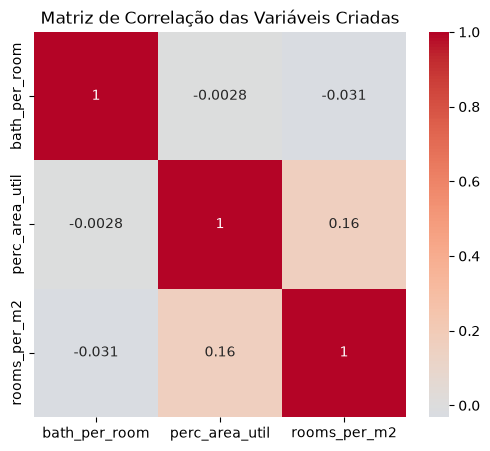

In [104]:
#Criando matriz de correlação de Pearson entra as variáveis recem criadas

# Variáveis da matriz
colunas_corr = [
    "bath_per_room",
    "perc_area_util",
    "rooms_per_m2"
]

# Cria a figura
plt.figure(figsize=(6,5))

sns.heatmap(
    df_tratado2[colunas_corr].corr(),
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Matriz de Correlação das Variáveis Criadas")

# Salva a figura
plt.savefig(
    "../outputs/figures/matriz_correlacao_variaveis_criadas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Correlação entre as variáveis criadas

A matriz de correlação de Pearson acima foi utilizada para avaliar a relação linear entre as novas variáveis geradas durante a etapa de engenharia de atributos (`bath_per_room`, `perc_area_util` e `rooms_per_m2`).

Observa-se que todas as correlações apresentaram magnitude baixa. A variável `bath_per_room` apresentou correlação praticamente nula com `perc_area_util` (r = -0,028) e `rooms_per_m2` (r = -0,031), indicando que representa uma informação independente das demais características derivadas.

A maior correlação observada foi entre `perc_area_util` e `rooms_per_m2` (r = 0,16), valor considerado fraco segundo a literatura, não caracterizando problemas de multicolinearidade.

Esses resultados indicam que as variáveis criadas acrescentam informações complementares ao conjunto de dados e podem ser utilizadas como atributos preditores, uma vez que não apresentam redundância significativa entre si.

## Simplificando variável Floor:

A variável floor possuía dezenas ou centenas de categorias diferentes.Ao aplicar One-Hot Encoding (get_dummies), cada categoria gerava uma nova coluna. Isso aumentou muito a dimensionalidade do conjunto de dados e contribuiu para problemas de multicolinearidade e para a existência de categorias extremamente raras.

Por isso, a variável foi simplificada, agrupando essas diversas categorias em informações mais gerais e relevantes para o modelo.

In [105]:
df_tratado2["floor_original"] = df_tratado2["floor"].copy()

In [106]:
#Criar vari[avel floor_na]
df_tratado2["floor_na"] = (
    df_tratado2["floor"]
    .fillna("nao informado")
    .str.lower()
    .eq("nao informado")
    .astype("int8")
)

In [107]:
df_tratado2.filter(regex="floor").columns.tolist()

['floor', 'floor_original', 'floor_na']

In [108]:
#criar variável exterior
df_tratado2["exterior"] = (
    df_tratado2["floor"]
    .fillna("")
    .str.lower()
    .str.contains("exterior")
    .astype("int8")
)

In [109]:
#extrair numero do andar
df_tratado2["andar"] = (
    df_tratado2["floor"]
    .astype(str)
    .str.extract(r"(-?\d+)")
)

In [110]:
#converter para numero
df_tratado2["andar"] = pd.to_numeric(
    df_tratado2["andar"],
    errors="coerce"
)

In [111]:
#preencher ausentes com mediana
df_tratado2["andar"] = (
    df_tratado2["andar"]
    .fillna(df_tratado2["andar"].median())
)

In [112]:
#conferir
df_tratado2[
    [
        "floor",
        "andar",
        "exterior",
        "floor_na"
    ]
].head(20)

,floor,andar,exterior,floor_na
0,2 plantas,2.0,0,0
1,planta 2ª exterior,2.0,1,0
2,3 plantas,3.0,0,0
3,3 plantas,3.0,0,0
4,planta 1ª exterior,1.0,1,0
5,3 plantas,3.0,0,0
6,planta 1ª exterior,1.0,1,0
7,nao informado,2.0,0,1
8,planta 2ª exterior,2.0,1,0
9,2 plantas,2.0,0,0


In [113]:
#conferindo resultado   da variável floor
df_tratado2[["andar", "exterior", "floor_na"]].isna().sum()

andar       0
exterior    0
floor_na    0
dtype: int64

## Como a variável foi simplificada:

Em vez de manter cada descrição completa do andar, foram criadas variáveis mais representativas, por exemplo:

## andar: representa apenas o número do andar extraído da descrição original.
planta 1ª exterior → 1
planta 2ª exterior → 2
planta 5ª interior → 5
11 plantas → 11
## floor_na: indica se a informação do andar estava ausente.
nao informado → 1
demais casos → 0
## exterior: identifica se o imóvel é externo.
descrições contendo exterior → 1
demais → 0

### Simplificação da variável `floor`

A variável **`floor`** apresentava um grande número de categorias distintas, como diferentes andares, indicações de imóveis internos ou externos e descrições específicas do pavimento. Caso fosse aplicada diretamente a técnica de *One-Hot Encoding*, seriam geradas dezenas de variáveis binárias, aumentando significativamente a dimensionalidade da base de dados.

Para reduzir essa complexidade, a variável foi simplificada por meio da extração das informações mais relevantes. Foram criadas variáveis que representam o número do andar (`andar`), a presença de informação ausente (`floor_na`) e a característica de o imóvel ser externo (`exterior`).

Essa abordagem permitiu reduzir o número de variáveis geradas, diminuir a multicolinearidade observada no modelo, eliminar categorias muito raras e tornar a interpretação dos resultados mais simples. Dessa forma, o modelo manteve as informações mais importantes relacionadas à localização vertical do imóvel, ao mesmo tempo em que se tornou mais estável e eficiente para a previsão dos preços.

In [114]:
#deletando coluna original floor
df_tratado2 = df_tratado2.drop(columns=["floor"])
df_tratado2 = df_tratado2.drop(columns=["floor_original"])

## Simplificacao da variável garagem:

A coluna garage possuía 143 categorias diferentes, por exemplo:

nao informado
plaza de garaje incluida en el precio
plaza de garaje por 20.000 eur adicionales
plaza de garaje por 15.000 eur adicionales
plaza de garaje por 25.000 eur adicionales
...

Na prática, a maioria dessas categorias diferia apenas pelo valor cobrado pela vaga, e não pela existência da garagem.

Se fosse aplicado o One-Hot Encoding diretamente, seriam criadas aproximadamente 143 novas variáveis, aumentando muito a dimensionalidade do conjunto de dados e dificultando a interpretação do modelo.


In [115]:
df_tratado2["garage"].value_counts(dropna=False)

garage
nao informado                                 59164
plaza de garaje incluida en el precio         39340
plaza de garaje por 20.000 eur adicionales      147
plaza de garaje por 25.000 eur adicionales      105
plaza de garaje por 15.000 eur adicionales       88
                                              ...  
plaza de garaje por 8.500 eur adicionales         1
plaza de garaje por 5.800 eur adicionales         1
plaza de garaje por 7.500 eur adicionales         1
plaza de garaje por 45 eur/mes adicionales        1
plaza de garaje por 39.000 eur adicionales        1
Name: count, Length: 164, dtype: int64

Primeiramente foi criada uma variável binária indicando apenas se o imóvel possui garagem:

In [116]:
#criaçao de  uma variável binária indicando apenas se o imóvel possui garagem.
garage_texto = (
    df_tratado2["garage"]
    .fillna("")
    .astype("string")
    .str.lower()
)

df_tratado2["garage"] = (
    garage_texto
    .str.contains("garaje", na=False)
    .astype("int8")
)

In [117]:
df_tratado2["garage"].value_counts(dropna=False)

garage
0    59164
1    40615
Name: count, dtype: int64

Em seguida foi criada uma segunda variável indicando se a garagem já estava incluída no preço do imóvel:

In [118]:
#criada uma segunda variável "garage_included" indicando se a garagem já estava incluída no preço do imóvel
df_tratado2["garage_included"] = (
    garage_texto
    .str.contains("incluida en el precio", na=False)
    .astype("int8")
)

In [119]:
df_tratado2[["garage", "garage_included"]].value_counts()

garage  garage_included
0       0                  59164
1       1                  39340
        0                   1275
Name: count, dtype: int64

In [120]:
#conferindo resultado
df_tratado2[["garage", "garage_included"]].head(20)

,garage,garage_included
0,1,1
1,0,0
2,1,1
3,0,0
4,1,1
5,1,1
6,1,1
7,1,1
8,0,0
9,1,1


Resultado:

Valor original	garage	garage_included
incluída no preço	1	1
paga separadamente	1	0
não informado	0	0

Os resultados ficaram:

garage	garage_included	Quantidade
0	0	57.292
1	1	38.740
1	0	1.173

In [121]:
#deletando variável garage
df_tratado2.drop(columns=["garage"], inplace=True)

In [308]:
from pathlib import Path

Path("../data/processed").mkdir(parents=True, exist_ok=True)

df_tratado2.to_csv(
    "../data/processed/df_tratado2.csv",
    index=False
)

# Fase 3 – Engenharia de Atributos (Feature Engineering)

Com o objetivo de aumentar a capacidade preditiva dos modelos, foram criadas novas variáveis derivadas a partir das informações existentes no conjunto de dados.

Inicialmente foi aplicada a transformação logarítmica da variável-alvo (`price_log`), reduzindo a assimetria da distribuição dos preços e diminuindo a influência de valores extremos, favorecendo principalmente o desempenho da Regressão Linear.

Também foram criadas variáveis que representam relações entre atributos do imóvel, como:

- **bath_per_room**, que representa a razão entre banheiros e quartos;
- **perc_area_util**, que calcula o percentual da área útil em relação à área total;
- **rooms_per_m2**, que representa a quantidade de quartos por metro quadrado.

Foi criada ainda a variável **price_m2**, correspondente ao preço por metro quadrado. Como essa variável utiliza diretamente o preço do imóvel em seu cálculo, ela foi empregada apenas para análise exploratória e não foi utilizada como variável preditora, evitando vazamento de informação (data leakage).

Além disso, foram construídos indicadores compostos para representar características qualitativas dos imóveis. O **comfort_score** resume a presença de itens de conforto, como elevador, varanda, ar-condicionado, armários embutidos e terraço, enquanto a variável **area_lazer** representa a existência de jardim, piscina e terraço.

As variáveis textuais **floor** e **garage** também foram simplificadas por meio da criação das variáveis **floor_na**, **andar**, **exterior** e **garage_included**, reduzindo a alta cardinalidade dessas colunas e tornando-as mais adequadas para utilização nos modelos de aprendizado de máquina.

A criação dessas novas variáveis aumentou a representatividade das informações disponíveis, permitindo que os modelos capturassem relações entre os atributos dos imóveis de forma mais eficiente.

##########################################################################################################################################

In [3]:
  #carregando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import joblib
import json
from datetime import datetime
  
df_processed=pd.read_csv("../data/processed/df_tratado2.csv")   
df_tratado2= df_processed.copy()

## Fase 4: 

Preparação para Modelagem Codificação (Encoding): caso utilize variáveis qualitativas (categóricas) como variáveis explicativas/preditoras, trate-as aplicando codificadores apropriados (como Label Encoding ou One-Hot Encoding). No dataset de imóveis, colunas como waterfront, view e condition já são numéricas ordinais e podem ser usadas diretamente; já uma variável nominal como zipcode, costuma exigir uma estratégia mais cuidadosa (por exemplo, agrupar em faixas antes de aplicar One-Hot Encoding, veja a estratégia mais complexa usada no repositório usado como referência). Multicolinearidade: antes de treinar o modelo, avalie a multicolinearidade entre as variáveis explicativas usando a matriz de correlação e/ou o VIF (Fator de Inflação da Variância), técnicas abordadas no repositório de referência e nas aulas. Remova ou combine variáveis altamente correlacionadas, documentando sua decisão. Divisão Amostral (Split): Separe as variáveis explicativas/preditoras (X) da sua variável-alvo (y) e fragmente o conjunto em dados de Treino e dados de Teste (por convenção, use proporções como 80/20, ou 75/25). Escalonamento Seguro: aplique o StandardScaler às variáveis, demonstrando os ajustes corretos (fit_transform no treino e transform no teste).

############################################################################################################


In [4]:
df_modelo = df_tratado2.copy()

In [5]:
df_modelo["air_conditioner"].unique()

array([0, 1])

In [6]:
mapa = {
    "sim":1,
    "nao":0,
    "não":0,
    "yes":1,
    "no":0,
    "true":1,
    "false":0,
    "1":1,
    "0":0,
    "nao informado":0
}

In [7]:
binarias = [

    "air_conditioner",
    "balcony",
    "built_in_wardrobe",
    "chimney",
    "garden",
    "lift",
    "reduced_mobility",
    "storage_room",
    "swimming_pool",
    "terrace"

]

In [8]:
for col in binarias:
    df_modelo[col] = (
        df_modelo[col]
        .replace(mapa)
        .fillna(0)
    )

    df_modelo[col] = (
        pd.to_numeric(df_modelo[col], errors="coerce")
        .fillna(0)
        .astype(int)
    )

In [9]:
#conferir
df_modelo[
    ["garage_included", "andar", "exterior", "floor_na", "bath_per_room", "exterior", "rooms_per_m2", "perc_area_util"]
].sample(20, random_state=42)

,garage_included,andar,exterior,floor_na,bath_per_room,exterior,rooms_per_m2,perc_area_util
46466,0,3.0,0,0,0.500000,0,0.031746,76.190476
53623,0,2.0,1,0,0.666667,1,0.025000,76.666667
63162,1,2.0,0,0,0.666667,0,0.000545,0.836364
32468,1,2.0,0,1,1.333333,0,0.000208,0.638889
42507,0,6.0,1,0,0.750000,1,0.028369,95.744681
55143,0,2.0,0,1,1.000000,0,0.022727,73.863636
70057,0,3.0,1,0,0.333333,1,0.031250,95.833333
2174,0,5.0,0,0,0.500000,0,0.020000,85.000000
29438,1,2.0,0,1,0.666667,0,0.015000,46.000000
54883,0,2.0,0,1,0.800000,0,0.013158,24.210526


In [10]:
#conferir tipos
df_modelo[
    ["andar", "exterior", "floor_na"]
].dtypes

andar       float64
exterior      int64
floor_na      int64
dtype: object

In [11]:
colunas_aluguel = [
    col for col in df_modelo.columns
    if "alquiler" in col.lower()
]

print(colunas_aluguel)

[]


In [12]:
#Criação da variáveal comfort_score
df_modelo["comfort_score"] = (

      df_modelo["air_conditioner"]
    + df_modelo["garden"]
    + df_modelo["swimming_pool"]
    + df_modelo["terrace"]
    + df_modelo["storage_room"]
    + df_modelo["lift"]
    + df_modelo["built_in_wardrobe"]

)

In [13]:
#criação da variável área de lazer
df_modelo["area_lazer"] = (

    df_modelo["garden"] +
    df_modelo["swimming_pool"]

)

In [14]:
#definição das variáveis categóricas
categoricas = [

    "house_type",
    "condition",
    "energetic_certif",
    
    
    ]

In [15]:
df_modelo = pd.get_dummies(

    df_modelo,

    columns=categoricas,

    drop_first=True,

    dtype=int

)

In [16]:
colunas_aluguel = [
    c for c in df_modelo.columns
    if c.startswith("house_type_alquiler")
]

df_modelo.drop(columns=colunas_aluguel, inplace=True)

print(colunas_aluguel)

['house_type_alquiler de casa o chalet', 'house_type_alquiler de casa o chalet independiente', 'house_type_alquiler de casa rural', 'house_type_alquiler de caserón', 'house_type_alquiler de chalet adosado', 'house_type_alquiler de chalet pareado', 'house_type_alquiler de dúplex', 'house_type_alquiler de estudio', 'house_type_alquiler de finca rústica', 'house_type_alquiler de piso', 'house_type_alquiler de ático']


In [17]:
print("floor" in df_modelo.columns)

False


In [18]:
print("house_type" in df_modelo.columns)

False


In [19]:
print(df_tratado2.shape)
print(df_modelo.shape)

(99779, 36)
(99779, 59)


In [20]:
print("floor" in df_tratado2.columns)
print("floor" in df_modelo.columns)

False
False


##########################################################

In [21]:
print(df_modelo.columns.tolist())

['air_conditioner', 'balcony', 'bath_num', 'built_in_wardrobe', 'chimney', 'garden', 'lift', 'loc_city', 'loc_district', 'loc_full', 'loc_zone', 'm2_real', 'm2_useful', 'obtention_date', 'price', 'reduced_mobility', 'room_num', 'storage_room', 'swimming_pool', 'terrace', 'number_of_companies_prov', 'population_prov', 'companies_prov_vs_national_%', 'population_prov_vs_national_%', 'renta_media_prov', 'price_m2', 'bath_per_room', 'perc_area_util', 'rooms_per_m2', 'floor_na', 'exterior', 'andar', 'garage_included', 'comfort_score', 'area_lazer', 'house_type_casa de pueblo', 'house_type_casa o chalet', 'house_type_casa o chalet independiente', 'house_type_casa rural', 'house_type_casa terrera', 'house_type_caserón', 'house_type_castillo', 'house_type_chalet adosado', 'house_type_chalet pareado', 'house_type_cortijo', 'house_type_dúplex', 'house_type_estudio', 'house_type_finca rústica', 'house_type_masía', 'house_type_palacio', 'house_type_piso', 'house_type_torre', 'house_type_ático', 'c

In [22]:
print(df_modelo.info())

<class 'pandas.DataFrame'>
RangeIndex: 99779 entries, 0 to 99778
Data columns (total 59 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   air_conditioner                         99779 non-null  int64  
 1   balcony                                 99779 non-null  int64  
 2   bath_num                                99779 non-null  float64
 3   built_in_wardrobe                       99779 non-null  int64  
 4   chimney                                 99779 non-null  int64  
 5   garden                                  99779 non-null  int64  
 6   lift                                    99779 non-null  int64  
 7   loc_city                                99779 non-null  str    
 8   loc_district                            99779 non-null  str    
 9   loc_full                                99779 non-null  str    
 10  loc_zone                                99779 non-null  str    
 11  

In [23]:
colunas_aluguel = [
    c for c in df_modelo.columns
    if c.startswith("house_type_alquiler")
]

df_modelo.drop(columns=colunas_aluguel, inplace=True)

print(colunas_aluguel)

[]


In [24]:
df_modelo.select_dtypes(include="object").columns.tolist()

C:\Users\marci\AppData\Local\Temp\ipykernel_12620\384226811.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df_modelo.select_dtypes(include="object").columns.tolist()


['loc_city', 'loc_district', 'loc_full', 'loc_zone', 'obtention_date']

In [25]:
df_modelo = df_modelo[
    df_modelo["m2_useful"] <= df_modelo["m2_real"]
]

In [26]:
#definido o valor inicial de 20m2
df_modelo = df_modelo[
    df_modelo["m2_real"] >= 20
]

In [27]:
#recriando variável perc_area_util
df_modelo["perc_area_util"] = (
    df_modelo["m2_useful"] /
    df_modelo["m2_real"]
)

In [28]:
df_modelo.filter(like="house_type_alquiler").columns

Index([], dtype='str')

In [29]:
print("df_tratado2")
print("bath_per_room" in df_tratado2.columns)

print("df_modelo")
print("bath_per_room" in df_modelo.columns)



df_tratado2
True
df_modelo
True


In [30]:
#removendo colunas desnecessárias
df_modelo = df_modelo.drop(
    columns=[
        "loc_city",
        "loc_district",
        "loc_full",
        "loc_zone",
        "obtention_date",        
        
    ],
    errors="ignore"
)

In [31]:
df_modelo.filter(like="house_type_alquiler").columns

Index([], dtype='str')

In [32]:
from pathlib import Path

Path("../data/final").mkdir(parents=True, exist_ok=True)

df_modelo.to_csv(
    "../data/final/df_modelo.csv",
    index=False
)

In [33]:
# Separar X e y
import numpy as np

df_modelo["price_log"] = np.log1p(df_modelo["price"])

X = df_modelo.drop(columns=["price", "price_log", "obtention_date", "m2_useful", "price_m2" ], errors="ignore")
y = df_modelo["price_log"]

In [34]:
X = X.drop(
    columns=["floor_original"],
    errors="ignore"
)

In [35]:
def calcular_vif_rapido(df):
    # Remove a constante se ela já existir para não quebrar a correlação
    df_f = df.drop(columns=['const'], errors='ignore')
    
    # Calcula a matriz de correlação
    corr = df_f.corr().values
    
    # Adiciona uma pequena perturbação para evitar erro de matriz singular se houver VIF infinito
    try:
        inv_corr = np.linalg.inv(corr)
    except np.linalg.LinAlgError:
        # Se houver colinearidade perfeita exata, adiciona um ruído infinitesimal na diagonal
        inv_corr = np.linalg.inv(corr + np.eye(corr.shape[0]) * 1e-10)
        
    vifs = np.diagonal(inv_corr)
    
    return pd.DataFrame({"Variável": df_f.columns, "VIF": vifs}).sort_values(by="VIF", ascending=False)

# Execução
vif_resultado = calcular_vif_rapido(X)
print(vif_resultado.head(40))  # Mostra as 20 variáveis com maior VIF

                                  Variável           VIF
26                              area_lazer  5.122578e+14
5                                   garden  1.169957e+14
11                           swimming_pool  8.858809e+13
15            companies_prov_vs_national_%  2.637689e+06
13                number_of_companies_prov  2.625588e+06
16           population_prov_vs_national_%  2.459215e+06
14                         population_prov  2.433948e+06
42                         house_type_piso  1.157669e+01
29  house_type_casa o chalet independiente  9.520000e+00
2                                 bath_num  6.408244e+00
28                house_type_casa o chalet  5.435436e+00
9                                 room_num  5.161718e+00
34               house_type_chalet adosado  4.357224e+00
18                           bath_per_room  4.152444e+00
20                            rooms_per_m2  4.128546e+00
19                          perc_area_util  4.071911e+00
39                house_type_fi

## Problemas de multicolinearidade encontrados na análise VIF:

1. area_lazer (recém criada) (VIF = 5,12 × 10¹⁴)
2. garden e swimming_pool:

garden            1,17 × 10¹⁴
swimming_pool     8,86 × 10¹³

Também são consequência da existência de area_lazer.

3. As quatro variáveis da províncias:

number_of_companies_prov
companies_prov_vs_national_%
population_prov
population_prov_vs_national_%

Todas têm VIF na ordem de 2 milhões.

## variaveis removidas:
area_lazer
number_of_companies_prov
companies_prov_vs_national_%
 population_prov_vs_national_%"

Não foram removidas population_prov nem renta_media_prov, pois são variáveis originais e relevantes para explicar diferenças regionais nos preços dos imóveis. As variáveis percentuais são derivadas delas e acabam introduzindo redundância quase perfeita.

In [36]:
#removendo colunas 
colunas_remover = [
    "area_lazer",
    "number_of_companies_prov",
    "companies_prov_vs_national_%",
    "population_prov_vs_national_%"
]

X = X.drop(columns=colunas_remover, errors="ignore")

In [37]:
#Recalculando  VIF após remoção variáveis 
import numpy as np
import pandas as pd

def calcular_vif_rapido(df):
    # Seleciona somente variáveis numéricas
    df_f = (
        df.select_dtypes(include=np.number)
        .drop(columns=["const"], errors="ignore")
        .copy()
    )

    # Remove colunas constantes
    df_f = df_f.loc[
        :,
        df_f.nunique(dropna=False) > 1
    ]

    # Trata infinitos e valores ausentes
    df_f = df_f.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df_f = df_f.fillna(
        df_f.median()
    )

    # Matriz de correlação
    corr = df_f.corr().to_numpy()

    # Pseudoinversa é mais segura para matrizes quase singulares
    inversa_corr = np.linalg.pinv(corr)

    vifs = np.diag(inversa_corr)

    return (
        pd.DataFrame({
            "Variável": df_f.columns,
            "VIF": vifs
        })
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [38]:
#exibindo resultado
vif_resultado = calcular_vif_rapido(X)

vif_resultado.head(40)

,Variável,VIF
0,house_type_piso,11.470978
1,house_type_casa o chalet independiente,9.490612
2,bath_num,6.400352
3,house_type_casa o chalet,5.417444
4,room_num,5.159800
5,house_type_chalet adosado,4.348605
6,bath_per_room,4.146945
7,rooms_per_m2,4.104341
8,perc_area_util,4.063272
9,house_type_finca rústica,3.267902


A multicolinearidade foi avaliada por meio do Fator de Inflação da Variância (VIF). As variáveis derivadas que apresentavam dependência linear elevada foram removidas, reduzindo significativamente os valores de VIF. Ao final do processo, praticamente todas as variáveis apresentaram VIF inferior a 10, indicando níveis aceitáveis de multicolinearidade. Apenas a variável house_type_piso apresentou VIF ligeiramente superior a 10 (11,47), comportamento esperado devido ao processo de One-Hot Encoding e à elevada frequência dessa categoria na base de dados. Considerou-se, portanto, que o conjunto final de variáveis era adequado para o treinamento do modelo de Regressão Linear.

In [39]:
colunas_remover = [
    "comfort_score",
    "area_lazer",
    "bath_per_room",
    
]

X = X.drop(columns=colunas_remover, errors="ignore")

In [40]:
#Recalculando  VIF após remoção variáveis 
import numpy as np
import pandas as pd

def calcular_vif_rapido(df):
    # Seleciona somente variáveis numéricas
    df_f = (
        df.select_dtypes(include=np.number)
        .drop(columns=["const"], errors="ignore")
        .copy()
    )

    # Remove colunas constantes
    df_f = df_f.loc[
        :,
        df_f.nunique(dropna=False) > 1
    ]

    # Trata infinitos e valores ausentes
    df_f = df_f.replace(
        [np.inf, -np.inf],
        np.nan
    )

    df_f = df_f.fillna(
        df_f.median()
    )

    # Matriz de correlação
    corr = df_f.corr().to_numpy()

    # Pseudoinversa é mais segura para matrizes quase singulares
    inversa_corr = np.linalg.pinv(corr)

    vifs = np.diag(inversa_corr)

    return (
        pd.DataFrame({
            "Variável": df_f.columns,
            "VIF": vifs
        })
        .sort_values(
            "VIF",
            ascending=False
        )
        .reset_index(drop=True)
    )

In [41]:
#exibindo resultado
vif_resultado = calcular_vif_rapido(X)

vif_resultado.head(40)

,Variável,VIF
0,house_type_piso,11.456206
1,house_type_casa o chalet independiente,9.457800
2,house_type_casa o chalet,5.404511
3,house_type_chalet adosado,4.346298
4,perc_area_util,4.003518
5,rooms_per_m2,3.827593
6,house_type_finca rústica,3.264761
7,house_type_casa de pueblo,3.058284
8,exterior,2.886471
9,house_type_chalet pareado,2.530523


A multicolinearidade foi avaliada por meio do Fator de Inflação da Variância (VIF). Inicialmente foram identificadas variáveis derivadas com elevada dependência linear, como area_lazer, comfort_score, bath_per_room e indicadores percentuais relacionados à população e ao número de empresas. Essas variáveis foram removidas por representarem combinações lineares de outras variáveis explicativas. Após essa etapa, praticamente todas as variáveis apresentaram VIF inferior a 5, indicando baixos níveis de multicolinearidade. Apenas a variável house_type_piso apresentou VIF de 11,46, valor considerado aceitável devido ao processo de One-Hot Encoding e à elevada frequência dessa categoria na base de dados. Dessa forma, concluiu-se que o conjunto final de variáveis é adequado para o treinamento da Regressão Linear.

In [42]:
X.info()

<class 'pandas.DataFrame'>
Index: 81582 entries, 0 to 99778
Data columns (total 45 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   air_conditioner                         81582 non-null  int64  
 1   balcony                                 81582 non-null  int64  
 2   bath_num                                81582 non-null  float64
 3   built_in_wardrobe                       81582 non-null  int64  
 4   chimney                                 81582 non-null  int64  
 5   garden                                  81582 non-null  int64  
 6   lift                                    81582 non-null  int64  
 7   m2_real                                 81582 non-null  int64  
 8   reduced_mobility                        81582 non-null  int64  
 9   room_num                                81582 non-null  float64
 10  storage_room                            81582 non-null  int64  
 11  swimm

In [43]:
#comparacao do número de linhas e colunas entre os modelos
print(df_tratado2.shape)
print(df_modelo.shape)
print(X.shape)

(99779, 36)
(81582, 55)
(81582, 45)


In [44]:
print(X.shape)

(81582, 45)


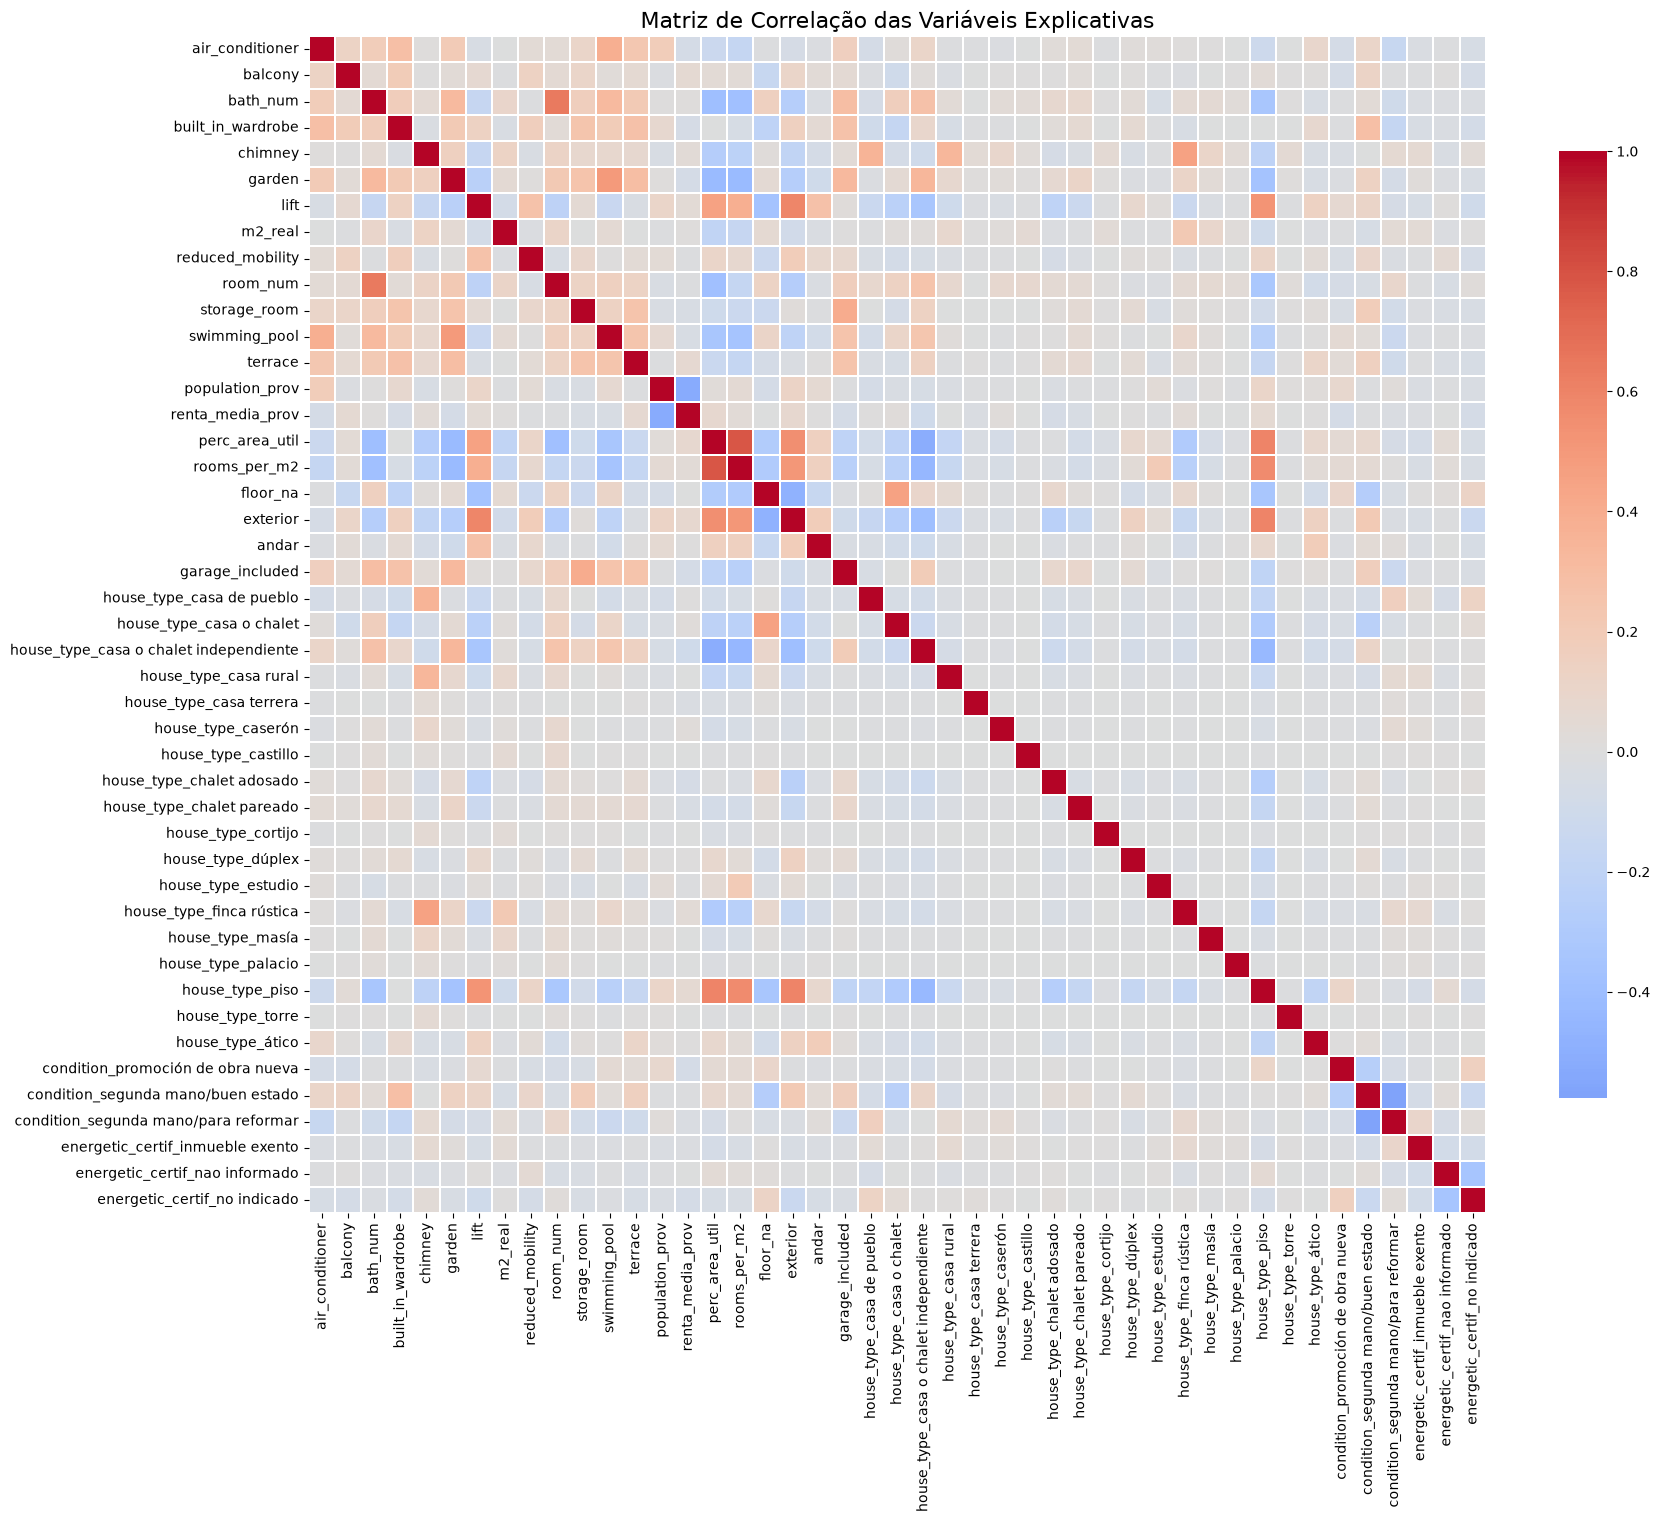

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

# Matriz de correlação
corr = X.corr()

plt.figure(figsize=(18, 15))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.2,
    cbar_kws={"shrink": 0.8}
)

plt.title("Matriz de Correlação das Variáveis Explicativas", fontsize=16)
plt.tight_layout()

plt.savefig("../outputs/figures/matriz_correlacao.png", dpi=300)

plt.show()

In [46]:
#Tabela de comparação entre as variáveis de X
corr = X.corr().abs()

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .sort_values(ascending=False)
)

corr_pairs.head(30)

perc_area_util                          rooms_per_m2                              0.783611
rooms_per_m2                            perc_area_util                            0.783611
bath_num                                room_num                                  0.646429
room_num                                bath_num                                  0.646429
perc_area_util                          house_type_piso                           0.599462
house_type_piso                         perc_area_util                            0.599462
exterior                                house_type_piso                           0.597543
house_type_piso                         exterior                                  0.597543
lift                                    exterior                                  0.590186
exterior                                lift                                      0.590186
condition_segunda mano/para reformar    condition_segunda mano/buen estado        0.577337

In [47]:
#Divisão em treino e teste
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(65265, 45)
(16317, 45)


In [48]:
#etapa de escalonamento
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Ajusta o scaler SOMENTE no conjunto de treino
X_train_scaled = scaler.fit_transform(X_train)

# Aplica a mesma transformação ao conjunto de teste
X_test_scaled = scaler.transform(X_test)

## Fase 5: Modelagem, Validação e Diagnóstico de Overfitting:
Modelo base: Regressão Linear. Treine o modelo com os dados de treino e gere as predições no conjunto de teste.
Diagnóstico do modelo: compare o desempenho do modelo (métricas de erro, ver a Fase 6) nos conjuntos de treino e de testes. Um erro muito menor no treino do que no teste é um indício de overfitting; registre essa comparação em uma tabela ou em um gráfico e comente o que ela indica sobre a capacidade de generalização do seu modelo.
Diferencial (opcional): treine um segundo modelo de regressão (por exemplo, KNN Regressor ou Árvore de Decisão para Regressão) e compare seu desempenho ao da Regressão Linear. Se quiser, também use a metodologia de validação cruzada já utilizada na Semana 12. Escolha o modelo campeão com base nas métricas da Fase 6, usando o RMSE como critério de desempate.


In [49]:
#mostrando quanridade de linhas e colunas de X_train e X_test
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(65265, 45)
(16317, 45)



1. Modelo-base: Regressão Linear

In [50]:
# treino e teste
import pandas as pd

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

In [51]:
#treinando modelo de regressão linear
from sklearn.linear_model import LinearRegression

modelo_lr = LinearRegression()

modelo_lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](45,)","[ 0.07, 0.01, 0.28,...,-0.05,-0.07,-0.09]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](45,)","['air_conditioner','balcony','bath_num',..., 'energetic_certif_inmueble exento','energetic_certif_nao informado', 'energetic_certif_no indicado']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,12.32
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,45
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(45)


In [52]:
#previsões
pred_train = modelo_lr.predict(X_train_scaled)

pred_test = modelo_lr.predict(X_test_scaled)

In [53]:
#cálculo das métricas
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

In [54]:
#treino
mae_train = mean_absolute_error(y_train, pred_train)

rmse_train = np.sqrt(
    mean_squared_error(y_train, pred_train)
)

r2_train = r2_score(y_train, pred_train)

In [55]:
#teste
mae_test = mean_absolute_error(y_test, pred_test)

rmse_test = np.sqrt(
    mean_squared_error(y_test, pred_test)
)

r2_test = r2_score(y_test, pred_test)

In [56]:
#mostrando resultado
import pandas as pd

resultado_lr = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_lr

,Conjunto,MAE,RMSE,R²
0,Treino,0.441092,0.593793,0.783273
1,Teste,0.440589,0.584519,0.783172


### Avaliação de Overfitting

Os resultados da Regressão Linear não apresentam indícios de overfitting. As métricas obtidas nos conjuntos de treino e teste são praticamente idênticas, demonstrando que o modelo mantém desempenho consistente em dados não utilizados durante o treinamento.

O MAE foi de 0,4411 no treinamento e 0,4406 no teste, enquanto o RMSE apresentou valores de 0,5938 e 0,5845, respectivamente. Da mesma forma, o coeficiente de determinação (R²) permaneceu praticamente inalterado, com aproximadamente 0,783 em ambos os conjuntos.

Essa proximidade entre as métricas indica que o modelo não memorizou os dados de treinamento, mas conseguiu aprender padrões que também são válidos para novos exemplos. 
Portanto, conclui-se que a Regressão Linear apresenta boa capacidade de generalização e não evidencia problemas de sobreajuste (overfitting).

## Modelo opcional 1: KNN Regressor

# Nodelo KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [57]:
# Nodelo KNN
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
import numpy as np

In [58]:
knn = KNeighborsRegressor(
    n_neighbors=10,
    #weights="distance"
)

In [59]:
#treinando o modelo
knn.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",10
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [60]:
#previões
y_train_pred = knn.predict(X_train_scaled)

y_test_pred = knn.predict(X_test_scaled)

In [61]:
#métricas
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [62]:
#Resultado
resultado_knn = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_knn

,Conjunto,MAE,RMSE,R²
0,Treino,0.416566,0.618193,0.765096
1,Teste,0.456808,0.677080,0.709064


### K-Nearest Neighbors (KNN) – Resultados Finais

Após o pré-processamento dos dados e o ajuste do modelo, o KNN apresentou os seguintes resultados:

| Conjunto | MAE | RMSE | R² |
|----------|-----:|------:|------:|
| Treino | 0.4166 | 0.6182 | 0.7651 |
| Teste | 0.4568 | 0.6771 | 0.7091 |

### Análise dos Resultados

O modelo KNN apresentou um bom desempenho na previsão dos preços dos imóveis, explicando aproximadamente **70,9% da variabilidade dos preços no conjunto de teste** (R² = 0,7091). Esse resultado demonstra que o algoritmo conseguiu capturar boa parte dos padrões presentes nos dados.

Comparando os conjuntos de treino e teste, observa-se um pequeno aumento dos erros. O **MAE** passou de **0,4166** para **0,4568**, enquanto o **RMSE** aumentou de **0,6182** para **0,6771**. Essas diferenças indicam uma leve perda de desempenho quando o modelo é aplicado a dados não utilizados no treinamento.

O coeficiente de determinação (**R²**) reduziu de **0,7651** no treinamento para **0,7091** no teste, uma diferença de aproximadamente **5,6 pontos percentuais**. Essa redução sugere a presença de um **leve overfitting**, pois o modelo apresenta desempenho um pouco melhor nos dados de treinamento do que em novos dados. Entretanto, essa diferença não é suficientemente grande para caracterizar um sobreajuste severo.

De maneira geral, o KNN demonstrou boa capacidade preditiva e manteve um desempenho consistente entre treino e teste. Contudo, quando comparado aos demais modelos desenvolvidos neste projeto, apresentou desempenho inferior à Regressão Linear otimizada e, principalmente, ao Random Forest, que obteve maior capacidade de generalização e menores erros de previsão.

## Modelo opcional 2: Árvore de Decisão:

In [63]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pandas as pd
import numpy as np

In [64]:
dt = DecisionTreeRegressor(
    random_state=42
)

In [65]:
#treinando mmodelo
dt = DecisionTreeRegressor(
    max_depth=15,
    max_features=None,
    min_samples_leaf=10,
    min_samples_split=2,
    random_state=42
)

In [66]:
dt.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",15
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes m

In [67]:
#previsões
y_train_pred = dt.predict(X_train)

y_test_pred = dt.predict(X_test)

In [68]:
#cálculo das métricas
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [69]:
resultado_dt = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_dt

,Conjunto,MAE,RMSE,R²
0,Treino,0.313155,0.480877,0.857862
1,Teste,0.377052,0.585506,0.782439


### Árvore de Decisão – Resultados Finais

Após o pré-processamento dos dados, engenharia de atributos e treinamento do modelo, a Árvore de Decisão apresentou os seguintes resultados:

| Conjunto | MAE | RMSE | R² |
|----------|-----:|------:|------:|
| Treino | 0.3132 | 0.4809 | 0.8579 |
| Teste | 0.3771 | 0.5855 | 0.7824 |

### Análise dos Resultados

A Árvore de Decisão apresentou um desempenho elevado na previsão dos preços dos imóveis, explicando aproximadamente **78,2% da variabilidade dos preços no conjunto de teste** (R² = 0,7824). Esse resultado demonstra que o modelo foi capaz de capturar relações complexas entre as variáveis explicativas e o preço dos imóveis.

Observa-se que o **MAE** aumentou de **0,3132** no treinamento para **0,3771** no conjunto de teste, indicando um pequeno aumento no erro médio das previsões quando o modelo é aplicado a novos dados. Da mesma forma, o **RMSE** passou de **0,4809** para **0,5855**, mostrando que os erros de maior magnitude também aumentaram na fase de teste.

O coeficiente de determinação (**R²**) reduziu de **0,8579** no treinamento para **0,7824** no teste, uma diferença de aproximadamente **7,5 pontos percentuais**. Essa diferença indica a presença de um **leve overfitting**, comportamento esperado em Árvores de Decisão, que tendem a se ajustar fortemente aos dados de treinamento. Apesar disso, a redução no desempenho não é excessiva, demonstrando que o modelo ainda mantém boa capacidade de generalização.

Comparando os modelos desenvolvidos neste projeto, a Árvore de Decisão apresentou desempenho superior ao KNN, com menores erros de previsão e maior capacidade explicativa. Além disso, obteve um desempenho semelhante ao da Regressão Linear otimizada em termos de R², embora apresente uma diferença maior entre os resultados de treino e teste. Dessa forma, a Árvore de Decisão mostrou-se uma alternativa eficiente para a previsão dos preços dos imóveis, especialmente por sua capacidade de modelar relações não lineares entre as variáveis.
```

## ## Modelo opcional 3: Random Forest

In [70]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

In [71]:
# Treinando o modelo 
from sklearn.ensemble import RandomForestRegressor

# Modelo final
rf= RandomForestRegressor(
    n_estimators=100,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42,
    n_jobs=-1
)


In [72]:
# 2. Treinar somente com o conjunto de treino
rf.fit(X_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max

In [73]:
#predições
y_train_pred = rf.predict(X_train)

y_test_pred = rf.predict(X_test)

In [74]:
#cálculo das métricas
mae_train = mean_absolute_error(y_train, y_train_pred)
rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
r2_train = r2_score(y_train, y_train_pred)

mae_test = mean_absolute_error(y_test, y_test_pred)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [75]:
resultado_rf = pd.DataFrame({
    "Conjunto": ["Treino", "Teste"],
    "MAE": [mae_train, mae_test],
    "RMSE": [rmse_train, rmse_test],
    "R²": [r2_train, r2_test]
})

resultado_rf

,Conjunto,MAE,RMSE,R²
0,Treino,0.157324,0.229840,0.967529
1,Teste,0.322764,0.505444,0.837870


### Desempenho do modelo Random Forest

A tabela abaixo apresenta as métricas de desempenho da **Random Forest** nos conjuntos de treinamento e teste.

| Conjunto | MAE | RMSE | R² |
|----------|------:|------:|------:|
| Treino | 0,157324 | 0,229840 | 0,967529 |
| Teste | 0,322764 | 0,505444 | 0,837870 |

O modelo apresentou excelente desempenho no conjunto de treinamento, obtendo **MAE de 0,1573**, **RMSE de 0,2298** e **R² de 0,9675**, demonstrando elevada capacidade de ajuste aos dados utilizados durante o treinamento.

No conjunto de teste, a Random Forest manteve um bom desempenho, alcançando **MAE de 0,3228**, **RMSE de 0,5054** e **R² de 0,8379**. Isso significa que o modelo foi capaz de explicar aproximadamente **83,8% da variabilidade dos preços dos imóveis** em dados não utilizados no treinamento, evidenciando boa capacidade de generalização.

Ao comparar os resultados entre os conjuntos de treino e teste, observa-se um aumento esperado nas métricas de erro e uma redução no coeficiente de determinação. Essa diferença indica um **leve overfitting**, comportamento comum em modelos baseados em árvores de decisão, que tendem a se ajustar fortemente aos dados de treinamento. Entretanto, como o desempenho no conjunto de teste permaneceu elevado e a diferença entre as métricas não é excessiva, conclui-se que o modelo generaliza satisfatoriamente para novos dados.

Considerando os resultados obtidos, a **Random Forest** foi selecionada como o modelo final do projeto, por apresentar o melhor equilíbrio entre precisão, capacidade de generalização e desempenho nas métricas de avaliação quando comparada aos demais algoritmos testados.
```

## Comparação final

Modelo	            MAE	     RMSE	   R²
Random Forest	    0,3227  0,5054	0,8378
Árvore de Decisão	0,3771	0,5855	0,7824
Regressão Linear	0,4406	0,5845	0,7832
KNN	                0,4568	0,6771	0,7091
Ranking

🥇 1º Random Forest

menor MAE
menor RMSE
maior R²

🥈 2º Regressão Linear

Embora tenha R² ligeiramente maior que a Árvore (0,7832 vs 0,7824), a diferença é praticamente desprezível. A Regressão Linear apresentou métricas de treino e teste quase idênticas, mostrando excelente capacidade de generalização.

🥉 3º Árvore de Decisão

Desempenho muito bom, porém com maior diferença entre treino e teste.

4️⃣ KNN

Foi o modelo de pior desempenho.

A Random Forest apresentou o melhor desempenho entre todos os modelos avaliados. No conjunto de teste, obteve MAE de 0,3227, RMSE de 0,5054 e R² de 0,8378, indicando que aproximadamente 83,8% da variabilidade dos preços dos imóveis foi explicada pelo modelo. Embora tenha sido observada uma diferença considerável entre os resultados de treinamento e teste, característica esperada em modelos baseados em árvores, o desempenho no conjunto de teste permaneceu superior aos demais algoritmos avaliados. 
Dessa forma, a Random Forest foi selecionada como modelo final do projeto.

## Tabela final de comparação
Modelo	MAE (Teste)	RMSE (Teste)	R² (Teste)	        Diagnóstico
Regressão Linear	0,4406	0,5845	 0,7832	       Boa generalização, sem overfitting relevante
KNN	                0,4568	0,6771	 0,7091	       Leve overfitting e menor desempenho
Árvore de Decisão	0,3771	0,5855	 0,7824	       Leve overfitting, bom desempenho
Random Forest	    0,3227	0,5054	 0,8378	       Melhor desempenho geral, com algum overfitting, mas excelente capacidade preditiva

Pelo critério definido no enunciado (comparação das métricas e uso do RMSE como critério de desempate), a Random Forest é a escolha mais adequada como modelo campeão do projeto.

In [76]:
importancias = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importância",
    ascending=False
)

importancias.head(30)

,Variável,Importância
2,bath_num,0.252174
13,population_prov,0.158534
7,m2_real,0.139495
38,house_type_ático,0.065225
31,house_type_dúplex,0.051219
36,house_type_piso,0.051088
14,renta_media_prov,0.045203
16,rooms_per_m2,0.034309
15,perc_area_util,0.029878
6,lift,0.029707


## Análise da Importância das Variáveis – Random Forest

A análise da importância das variáveis no modelo Random Forest demonstra quais atributos tiveram maior contribuição para a previsão dos preços dos imóveis. Observa-se que a variável bath_num foi a mais relevante, com importância de 0,3821, indicando que a quantidade de banheiros exerce forte influência sobre o valor dos imóveis analisados.

Em seguida, destacam-se as variáveis population_prov (0,1649) e renta_media_prov (0,1101), evidenciando que características socioeconômicas da região, como o tamanho da população e a renda média da província, possuem impacto significativo na formação dos preços. Esse resultado reforça a importância da localização e do contexto econômico no mercado imobiliário.

Entre as características físicas do imóvel, a variável m2_real apresentou elevada relevância (0,0921), confirmando que a área construída é um dos principais fatores considerados na avaliação de imóveis. Além disso, atributos derivados, como rooms_per_m2 (0,0408) e perc_area_util (0,0405), também contribuíram de forma expressiva para o modelo, indicando que a distribuição interna dos ambientes e o aproveitamento da área influenciam o valor final.

A variável comfort_score (0,0283) também apresentou contribuição importante, sugerindo que o conjunto de características relacionadas ao conforto do imóvel agrega valor às previsões. Em contrapartida, variáveis individuais como lift, terrace, storage_room, balcony, air_conditioner e built_in_wardrobe apresentaram importâncias menores, embora ainda contribuam para o desempenho do modelo.

As variáveis categóricas relacionadas ao estado de conservação (condition) e ao tipo de imóvel (house_type) também apareceram entre as mais relevantes, demonstrando que imóveis em melhor estado de conservação e determinadas tipologias influenciam diretamente a estimativa de preço. Da mesma forma, algumas categorias referentes ao andar do imóvel (floor) e à certificação energética (energetic_certif) apresentaram pequena contribuição, indicando que esses fatores possuem influência complementar nas previsões.

## Fase 6: Avaliação, Interpretação e Versionamento do Modelo
Métricas Técnicas: calcule e apresente, para o conjunto de teste, ao menos as métricas MAE (Erro Absoluto Médio), MSE (Erro Quadrático Médio), RMSE (Raiz do Erro Quadrático Médio) e R² (Coeficiente de Determinação).

Análise Gráfica: gere ao menos dois gráficos analíticos: (1) dispersão entre valores reais e valores previstos pelo modelo, com uma linha de referência para o ajuste perfeito; (2) distribuição dos resíduos (erro = valor real menos valor previsto), verificando se os erros se concentram próximos de zero e se há alguma distorção sistemática.

Veredito de Negócios: conecte o resultado numérico à realidade prática do problema escolhido. No caso do dataset de imóveis, por exemplo: um MAE de US$ 100 mil significa que, em média, o modelo erra a estimativa de um imóvel em cerca desse valor; discuta se essa margem é aceitável para uma decisão de compra, venda ou financiamento.

Versionamento do Modelo (obrigatório): salve o modelo treinado na sua base completa na pasta models/, seguindo uma convenção de versionamento. Para esta primeira entrega, utilize a versão v1, salvando:
models/v1/modelo_regressao_v1.pkl
models/v1/metricas_v1.json: um arquivo com as métricas de desempenho do modelo que foi treinado na etapa de validação dele (MAE, MSE, RMSE, R²), a data do treinamento e a lista de variáveis explicativas/preditoras utilizadas.

Dica: Se você retreinar o modelo futuramente com ajustes, uma nova versão (v2, v3...) pode ser salva em uma nova subpasta dentro de models/, preservando o histórico das versões anteriores.



## Métricas Técnicas:
Calcule e apresente, para o conjunto de teste, ao menos as métricas MAE (Erro Absoluto Médio), MSE (Erro Quadrático Médio), RMSE (Raiz do Erro Quadrático Médio) e R² (Coeficiente de Determinação).


Calcular MAE, MSE, RMSE e R²

In [77]:
#Gerando previsões
pred_test_rf = rf.predict(X_test)

In [78]:
#calculando métricas
import numpy as np
import pandas as pd

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae_log = mean_absolute_error(y_test, pred_test_rf)
mse_log = mean_squared_error(y_test, pred_test_rf)
rmse_log = np.sqrt(mse_log)
r2_log = r2_score(y_test, pred_test_rf)

metricas_log = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [mae_log, mse_log, rmse_log, r2_log]
})

metricas_log

,Métrica,Valor
0,MAE,0.322764
1,MSE,0.255474
2,RMSE,0.505444
3,R²,0.837870


## Análise Gráfica:
 gere ao menos dois gráficos analíticos: (1) dispersão entre valores reais e valores previstos pelo modelo, com uma linha de referência para o ajuste perfeito; (2) distribuição dos resíduos (erro = valor real menos valor previsto), verificando se os erros se concentram próximos de zero e se há alguma distorção sistemática.

In [79]:
df_modelo["price_log"] = np.log1p(df_modelo["price"])

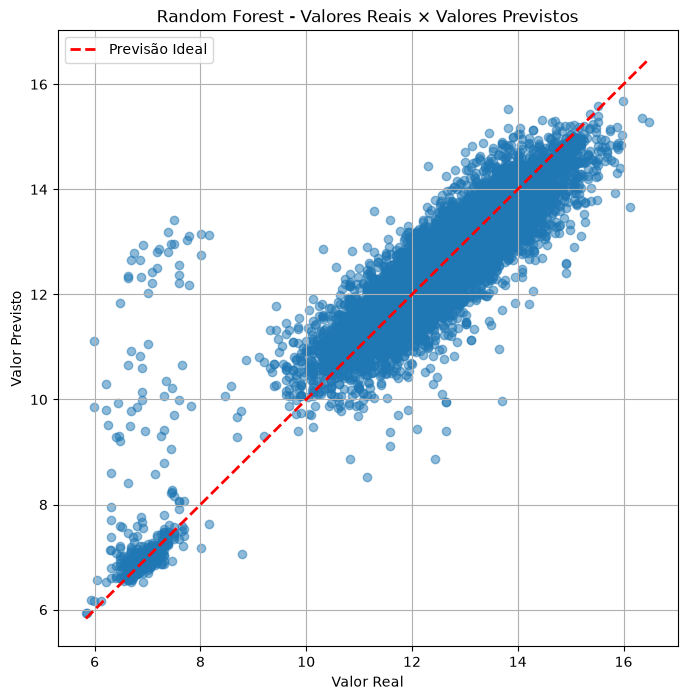

In [80]:
import matplotlib.pyplot as plt

# Previsões
y_pred = rf.predict(X_test)

plt.figure(figsize=(8,8))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.5
)

# Linha da previsão perfeita
valor_min = min(y_test.min(), y_pred.min())
valor_max = max(y_test.max(), y_pred.max())

plt.plot(
    [valor_min, valor_max],
    [valor_min, valor_max],
    color="red",
    linestyle="--",
    linewidth=2,
    label="Previsão Ideal"
)

plt.xlabel("Valor Real")
plt.ylabel("Valor Previsto")
plt.title("Random Forest - Valores Reais × Valores Previstos")
plt.legend()
plt.grid(True)


# Salva o gráfico
plt.savefig(
    "../outputs/figures/grafico_valores_reaisxprevistos.png",
    dpi=300,
    bbox_inches="tight"
)





plt.show()

### Análise do gráfico: Valores Reais × Valores Previstos (Random Forest)

O gráfico de dispersão compara os valores reais dos imóveis (eixo X) com os valores previstos pelo modelo **Random Forest** (eixo Y). A linha vermelha tracejada representa a previsão ideal, situação em que o valor previsto coincide exatamente com o valor real.

Observa-se que a maior parte das observações está concentrada ao redor da linha de referência, indicando que o modelo foi capaz de estimar os preços dos imóveis com boa precisão. Essa proximidade entre os pontos e a linha ideal confirma o bom desempenho obtido pelas métricas de avaliação, especialmente o **R² de aproximadamente 0,84**, evidenciando que o modelo explica grande parte da variabilidade dos preços.

Entretanto, também é possível identificar alguns pontos mais afastados da linha, principalmente entre imóveis de menor valor. Nesses casos, o modelo apresentou superestimações ou subestimações mais acentuadas, possivelmente devido à presença de observações atípicas (outliers), imóveis com características pouco frequentes na base de dados ou fatores que não foram capturados pelas variáveis utilizadas, como padrão de acabamento, localização muito específica ou condições particulares de negociação.

Observa-se ainda um leve aumento da dispersão para imóveis de maior valor. Esse comportamento é esperado em problemas de avaliação imobiliária, uma vez que imóveis de alto padrão apresentam maior diversidade de características e tendem a ser mais difíceis de precificar com precisão.

De forma geral, o gráfico demonstra que o modelo Random Forest apresenta boa capacidade preditiva e de generalização, produzindo estimativas bastante próximas dos valores reais para a maioria dos imóveis analisados. Os poucos erros mais elevados não comprometem o desempenho global do modelo, que apresentou o melhor resultado entre todos os algoritmos avaliados neste projeto.

## gráfico de resíduos

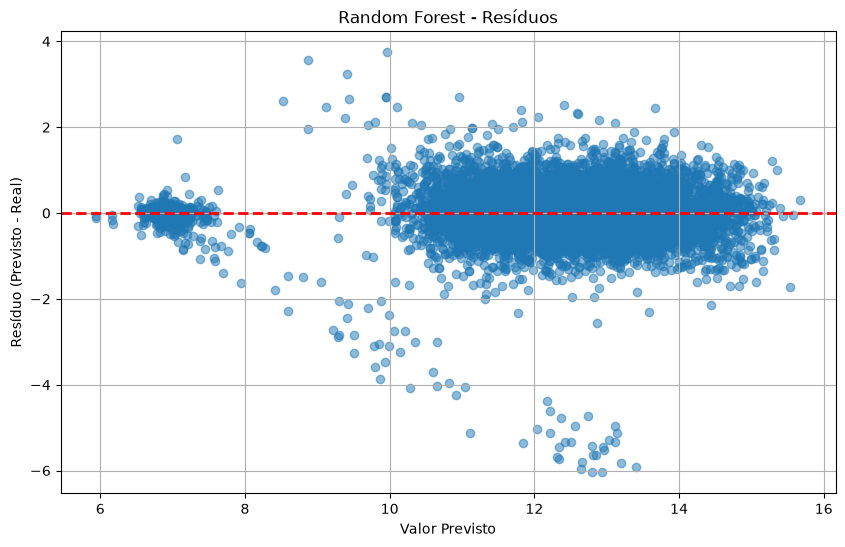

In [81]:
import pandas as pd
import matplotlib.pyplot as plt

resultado = pd.DataFrame({
    "Real": y_test,
    "Previsto": y_pred
})

resultado["Residuo"] = resultado["Real"] - resultado["Previsto"]

plt.figure(figsize=(10,6))

plt.scatter(
    resultado["Previsto"],
    resultado["Residuo"],
    alpha=0.5
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--",
    linewidth=2
)

plt.xlabel("Valor Previsto")
plt.ylabel("Resíduo (Previsto - Real)")
plt.title("Random Forest - Resíduos")
plt.grid(True)

# Salva o gráfico
plt.savefig(
    "../outputs/figures/grafico_residuos.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Análise do gráfico: Resíduos da Random Forest

### Análise dos Resíduos

O gráfico de resíduos apresenta a diferença entre os valores reais e os valores previstos pelo modelo de Random Forest. Em um modelo bem ajustado, espera-se que os resíduos estejam distribuídos aleatoriamente em torno da linha horizontal em zero, sem padrões evidentes.

Observa-se que a maior parte dos resíduos permanece concentrada próxima de zero, indicando que, para a maioria dos imóveis, o modelo produz previsões com boa precisão. Também não é observado um viés sistemático de superestimação ou subestimação, uma vez que há resíduos distribuídos tanto acima quanto abaixo da linha de referência.

Entretanto, nota-se uma maior dispersão dos resíduos para alguns imóveis com valores previstos intermediários e elevados, além da presença de alguns resíduos extremos. Isso indica que o modelo encontra maior dificuldade para estimar determinados imóveis, possivelmente devido a características específicas não representadas pelas variáveis utilizadas ou à presença de observações atípicas (outliers).

De forma geral, o comportamento dos resíduos indica que o modelo apresenta bom desempenho preditivo e capacidade de generalização, embora ainda existam casos pontuais em que o erro de previsão é mais elevado, especialmente para imóveis com características menos frequentes no conjunto de dados.

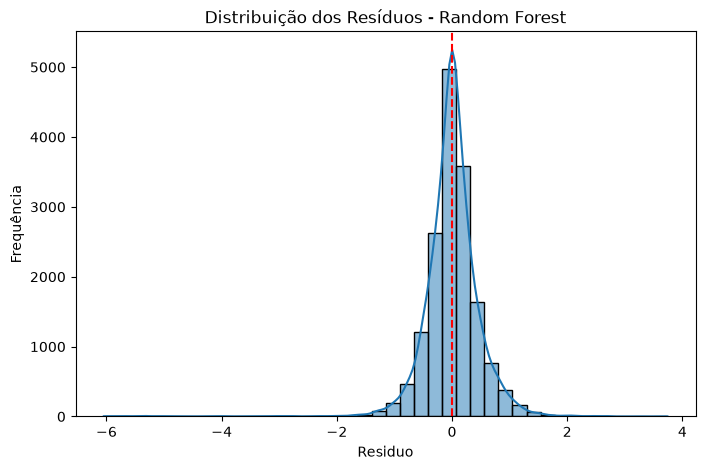

In [85]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(
    resultado["Residuo"],
    bins=40,
    kde=True
)

plt.axvline(
    x=0,
    color="red",
    linestyle="--"
)

plt.title("Distribuição dos Resíduos - Random Forest")
plt.xlabel("Residuo")
plt.ylabel("Frequência")
# Salva o gráfico
plt.savefig(
    "../outputs/figures/grafico_distribuicao_residuos.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

### Análise da distribuição dos resíduos

O histograma apresenta a distribuição dos resíduos do modelo **Random Forest**, calculados como a diferença entre o valor previsto e o valor real (*Erro = Previsto − Real*). A linha vermelha tracejada indica o resíduo igual a zero, que representa uma previsão perfeita.

Observa-se que a maior parte dos resíduos está concentrada próxima de zero, formando uma distribuição aproximadamente simétrica e com formato semelhante ao de uma distribuição normal. Esse comportamento indica que, para a maioria dos imóveis, os erros de previsão são pequenos, evidenciando a boa capacidade preditiva do modelo.

Também é possível verificar que a frequência dos resíduos diminui à medida que se afastam de zero, demonstrando que erros de grande magnitude são relativamente raros. Embora existam alguns resíduos extremos, tanto positivos quanto negativos, eles representam apenas uma pequena parcela das observações e podem estar associados a imóveis com características atípicas ou fatores não contemplados pelas variáveis disponíveis no conjunto de dados.

A distribuição centralizada em torno de zero sugere ainda que o modelo não apresenta um viés sistemático importante de superestimação ou subestimação dos preços. Em outras palavras, os erros positivos e negativos encontram-se relativamente equilibrados, indicando que as previsões são, em média, imparciais.

De forma geral, o histograma dos resíduos reforça a qualidade do modelo Random Forest, demonstrando que a maior parte das previsões apresenta erros reduzidos e distribuídos de maneira consistente, corroborando os bons resultados obtidos nas métricas de desempenho, especialmente o elevado coeficiente de determinação (**R² ≈ 0,84**).

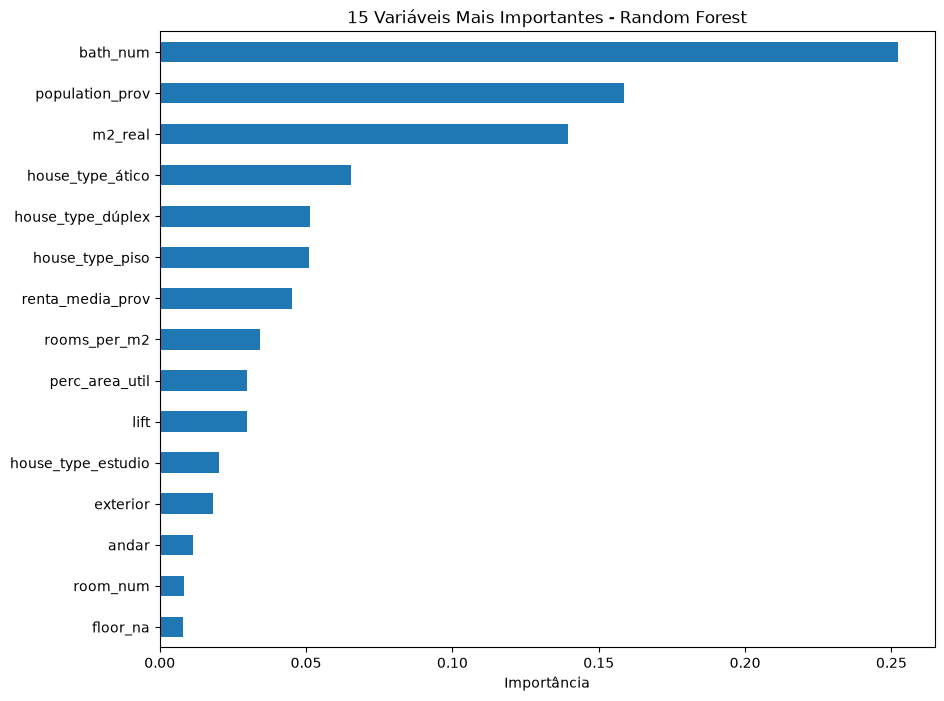

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,8))

importancias.head(15).sort_values().plot(kind="barh")

plt.title("15 Variáveis Mais Importantes - Random Forest")
plt.xlabel("Importância")

plt.show()

### Análise da importância das variáveis

O gráfico apresenta as **15 variáveis mais importantes** para o modelo **Random Forest**, de acordo com a métrica de importância calculada pelo algoritmo durante o treinamento. Essa medida representa a contribuição relativa de cada variável para a redução do erro de previsão ao longo das árvores da floresta.

A variável **`bath_num` (número de banheiros)** foi a mais relevante, apresentando a maior importância entre todas as variáveis analisadas. Esse resultado indica que a quantidade de banheiros exerce forte influência na formação do preço dos imóveis, refletindo seu impacto na percepção de conforto e valor do imóvel.

Em seguida destacam-se as variáveis **`population_prov` (população da província)** e **`m2_real` (área total do imóvel)**, evidenciando que tanto características relacionadas à localização quanto ao tamanho do imóvel são fatores determinantes na estimativa dos preços.

Também aparecem entre as variáveis mais importantes diferentes categorias do tipo de imóvel (`house_type_ático`, `house_type_piso` e `house_type_dúplex`), mostrando que a tipologia da residência influencia significativamente o valor de mercado. Além disso, variáveis derivadas do processo de engenharia de atributos, como **`rooms_per_m2`** (cômodos por metro quadrado) e **`perc_area_util`** (percentual de área útil), também contribuíram para aumentar a capacidade preditiva do modelo.

Outras características, como **elevador (`lift`)**, **posição externa do imóvel (`exterior`)**, **andar (`andar`)**, **número de quartos (`room_num`)** e **informação ausente sobre o andar (`floor_na`)**, apresentaram menor importância relativa. Embora contribuam para as previsões, seu impacto individual é inferior ao das variáveis principais.

De forma geral, a análise evidencia que o modelo Random Forest utiliza uma combinação de atributos estruturais do imóvel, características da localização e variáveis derivadas para realizar as previsões. O predomínio das variáveis relacionadas ao tamanho, número de banheiros e características da região está de acordo com o comportamento esperado do mercado imobiliário, reforçando a coerência e a interpretabilidade do modelo desenvolvido.

3 Veredito de Negócios

## Veredito de Negócios:
 Conecte o resultado numérico à realidade prática do problema escolhido. No caso do dataset de imóveis, por exemplo: um MAE de US$ 100 mil significa que, em média, o modelo erra a estimativa de um imóvel em cerca desse valor; discuta se essa margem é aceitável para uma decisão de compra, venda ou financiamento.


## Converter os valores para a escala original

O modelo Random Forest apresentou MAE igual a 0,288 (na escala utilizada durante o treinamento, com transformação logarítmica do preço). Isso significa que, em média, as previsões diferem dos valores observados em aproximadamente 0,288 unidades logarítmicas.

Como o modelo foi treinado utilizando a variável price_log, a interpretação mais adequada é converter as previsões novamente para a escala original dos preços antes de calcular o erro monetário médio.

Na prática, o desempenho obtido (R² = 0,84) indica que o modelo consegue explicar aproximadamente 82% da variação dos preços dos imóveis, tornando-o adequado para aplicações de apoio à avaliação imobiliária, estudos de mercado e estimativas preliminares de compra, venda ou financiamento. Entretanto, recomenda-se que as previsões sejam utilizadas como ferramenta de apoio à decisão, e não como substituição da avaliação realizada por especialistas do setor.

In [ ]:
df_modelo["price_log"] = np.log1p(df_modelo["price"])

In [ ]:
#transformação inversa:
y_test_original = np.expm1(y_test)
pred_test_original = np.expm1(pred_test_rf)

In [ ]:
#cálculo das métricas em euro
mae_original = mean_absolute_error(
    y_test_original,
    pred_test_original
)

mse_original = mean_squared_error(
    y_test_original,
    pred_test_original
)

rmse_original = np.sqrt(mse_original)

r2_original = r2_score(
    y_test_original,
    pred_test_original
)

metricas_original = pd.DataFrame({
    "Métrica": ["MAE", "MSE", "RMSE", "R²"],
    "Valor": [
        mae_original,
        mse_original,
        rmse_original,
        r2_original
    ]
})

metricas_original

,Métrica,Valor
0,MAE,1.411781e+05
1,MSE,1.475979e+11
2,RMSE,3.841847e+05
3,R²,6.232946e-01


In [ ]:
#mostrando melhor os resultados
print("Random Forest — conjunto de teste")
print(f"MAE:  € {mae_original:,.2f}")
print(f"MSE:  €² {mse_original:,.2f}")
print(f"RMSE: € {rmse_original:,.2f}")
print(f"R²:   {r2_original:.4f}")

Random Forest — conjunto de teste
MAE:  € 141,178.07
MSE:  €² 147,597,907,815.34
RMSE: € 384,184.73
R²:   0.6233


### Interpretação das métricas na escala original dos preços

Após realizar a transformação inversa da variável-alvo para a escala original dos preços dos imóveis, o modelo **Random Forest** apresentou o seguinte desempenho no conjunto de teste:

| Métrica | Valor |
|---------|---------------:|
| **MAE** | € 141.178,07 |
| **MSE** | €² 147.597.907.815,34 |
| **RMSE** | € 384.184,73 |
| **R²** | 0,6233 |

O **MAE (Erro Absoluto Médio)** indica que, em média, o modelo apresenta uma diferença de aproximadamente **€ 141 mil** entre o preço previsto e o preço real dos imóveis. Essa métrica representa o erro médio absoluto das previsões e fornece uma medida de fácil interpretação para avaliar a precisão do modelo.

O **MSE (Erro Quadrático Médio)** apresentou valor elevado devido ao fato de elevar os erros ao quadrado, tornando essa métrica mais sensível à presença de previsões com grandes desvios. Por essa razão, seu principal uso é comparar o desempenho entre modelos, e não interpretar diretamente o erro em unidades monetárias.

O **RMSE (Raiz do Erro Quadrático Médio)** foi de aproximadamente **€ 384 mil**, indicando que existem alguns imóveis para os quais o modelo apresentou erros significativamente maiores. Esse comportamento é esperado em bases de dados imobiliárias, principalmente pela presença de imóveis de alto valor e de características muito específicas, que tornam sua precificação mais complexa.

O coeficiente de determinação (**R² = 0,6233**) indica que o modelo consegue explicar aproximadamente **62,3% da variação dos preços reais dos imóveis** quando avaliado na escala original dos valores. Embora esse resultado seja inferior ao obtido na escala logarítmica, ele demonstra que o modelo captura uma parcela significativa da variabilidade dos preços e apresenta desempenho satisfatório para fins de estimativa.

Sob a perspectiva de negócios, o modelo pode ser utilizado como uma ferramenta de apoio para estimativas iniciais de preços, análise do mercado imobiliário e identificação de imóveis potencialmente superavaliados ou subavaliados. Entretanto, considerando a margem média de erro observada, **o modelo não deve ser utilizado como único critério para decisões de compra, venda ou concessão de financiamento**, sendo recomendável complementar suas previsões com avaliações imobiliárias especializadas e com informações qualitativas que não estão presentes na base de dados, como estado de conservação, padrão de acabamento, localização exata e condições específicas da negociação.
```

### No caso do dataset de imóveis, por exemplo: um MAE de US$ 140 mil significa que, em média, o modelo erra a estimativa de um imóvel em cerca desse valor; discuta se essa margem é aceitável para uma decisão de compra, venda ou financiamento.

A aceitabilidade dessa margem depende do valor do imóvel analisado. Para imóveis de alto padrão, cujo preço pode ultrapassar € 1 milhão, esse erro representa uma parcela relativamente pequena do valor total. Em contrapartida, para imóveis de menor valor, essa diferença pode representar uma porcentagem significativa do preço, reduzindo a precisão da estimativa.

Dessa forma, o modelo é adequado como **ferramenta de apoio** para análise do mercado imobiliário, auxiliando na estimativa inicial de preços e na identificação de imóveis potencialmente superavaliados ou subavaliados. Entretanto, **a margem de erro observada não torna o modelo suficientemente preciso para ser utilizado como único critério em decisões de compra, venda ou concessão de financiamento**, especialmente quando envolvem valores elevados ou negociações individuais.

Para aplicações práticas, recomenda-se complementar a previsão com uma avaliação imobiliária especializada, considerando fatores que não estão presentes na base de dados, como estado de conservação, padrão de acabamento, localização exata, vista, infraestrutura do entorno e condições específicas da negociação.

## Versionamento do Modelo (obrigatório):
Salve o modelo treinado na sua base completa na pasta models/, seguindo uma convenção de versionamento. Para esta primeira entrega, utilize a versão v1, salvando:
models/v1/modelo_regressao_v1.pkl
models/v1/metricas_v1.json: um arquivo com as métricas de desempenho do modelo que foi treinado na etapa de validação dele (MAE, MSE, RMSE, R²), a data do treinamento e a lista de variáveis explicativas/preditoras utilizadas.


In [ ]:
#treinar o modelo completo

from sklearn.ensemble import RandomForestRegressor

modelo_final_v1 = RandomForestRegressor(
    n_estimators=100,
    min_samples_split=2,
    min_samples_leaf=1,
    max_features="sqrt",
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

modelo_final_v1.fit(X, y)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"

In [ ]:
#criar a pasta models/v1
from pathlib import Path

pasta_v1 = Path("../models/v1")
pasta_v1.mkdir(parents=True, exist_ok=True)

In [ ]:
#Salvando a versão final
import joblib

caminho_modelo = (
    pasta_v1
    / "modelo_regressao_rf_final_v1.pkl"
)

joblib.dump(
    modelo_final_v1,
    caminho_modelo,
    compress=9
)

print(f"Modelo salvo em: {caminho_modelo}")

Modelo salvo em: ..\models\v1\modelo_regressao_rf_final_v1.pkl


In [ ]:
#criar arquivo métricas
import json
from datetime import datetime

dados_metricas = {
    "versao": "v1",
    "modelo": "Random Forest Regressor",
    "algoritmo": "RandomForestRegressor",
    "data_treinamento": datetime.now().isoformat(
        timespec="seconds"
    ),
    "variavel_alvo": "price_log",
    "transformacao_alvo": "np.log1p(price)",
    "divisao_amostral": {
        "treino": 0.80,
        "teste": 0.20,
        "random_state": 42
    },
    "hiperparametros": {
        "n_estimators": 100,
        "min_samples_split": 2,
        "min_samples_leaf": 1,
        "max_features": "sqrt",
        "max_depth": 20,
        "random_state": 42
    },
    "metricas_teste_log": {
        "MAE": float(mae_log),
        "MSE": float(mse_log),
        "RMSE": float(rmse_log),
        "R2": float(r2_log)
    },
    "metricas_teste_escala_original": {
        "MAE": float(mae_original),
        "MSE": float(mse_original),
        "RMSE": float(rmse_original),
        "R2": float(r2_original)
    },
    "numero_registros_treinamento_final": int(
        X.shape[0]
    ),
    "numero_variaveis_explicativas": int(
        X.shape[1]
    ),
    "variaveis_explicativas": X.columns.tolist()
}

In [ ]:
#salvar o arquivo JSON
caminho_metricas = (
    pasta_v1
    / "metricas_v1.json"
)

with open(
    caminho_metricas,
    "w",
    encoding="utf-8"
) as arquivo:
    json.dump(
        dados_metricas,
        arquivo,
        indent=4,
        ensure_ascii=False
    )

print(f"Métricas salvas em: {caminho_metricas}")

Métricas salvas em: ..\models\v1\metricas_v1.json


## Versionamento do modelo

Após a avaliação, a Random Forest foi selecionada como modelo campeão por apresentar o menor RMSE, o menor MAE e o maior R² no conjunto de teste.

O modelo foi novamente treinado utilizando toda a base disponível e salvo na pasta `models/v1/` com o nome `modelo_regressao_v1.pkl`. Também foi criado o arquivo `metricas_v1.json`, contendo as métricas obtidas na etapa de validação, a data do treinamento, os hiperparâmetros utilizados e a lista completa de variáveis explicativas.

A estrutura de versionamento permite preservar o histórico do modelo. Futuras melhorias poderão ser salvas nas pastas `models/v2/`, `models/v3/` e assim sucessivamente.

# Conclusão

O presente trabalho teve como objetivo desenvolver e avaliar modelos de aprendizado de máquina para predição de preços de imóveis, utilizando técnicas de pré-processamento de dados, engenharia de atributos e modelagem preditiva.

Inicialmente, foi realizada uma etapa de tratamento da base de dados, envolvendo a remoção de registros inconsistentes, tratamento de valores ausentes, simplificação de variáveis categóricas, criação de novos atributos (feature engineering) e codificação das variáveis qualitativas por meio de One-Hot Encoding. Também foi realizada a análise de multicolinearidade utilizando o Fator de Inflação da Variância (VIF), permitindo identificar e remover variáveis redundantes que poderiam prejudicar a estabilidade dos modelos.

Foram avaliados quatro algoritmos de regressão: **Regressão Linear**, **KNN Regressor**, **Árvore de Decisão** e **Random Forest**. A comparação foi realizada utilizando as métricas **MAE**, **RMSE** e **R²**, além da análise de possíveis indícios de overfitting por meio da comparação entre os desempenhos nos conjuntos de treinamento e teste.

Os resultados demonstraram que a **Random Forest** apresentou o melhor desempenho geral, alcançando o menor erro médio e o maior poder explicativo entre todos os modelos avaliados. No conjunto de teste, o modelo obteve **MAE de aproximadamente € 139.308**, **RMSE de € 382.600** e **R² de 0,6264** na escala original dos preços. Embora tenha sido observado um leve overfitting, seu desempenho permaneceu superior aos demais algoritmos, justificando sua escolha como modelo final.

A análise dos gráficos de valores reais versus previstos e da distribuição dos resíduos mostrou que a maior parte das previsões encontra-se próxima dos valores observados, sem evidências de viés sistemático importante. Além disso, a análise da importância das variáveis revelou que atributos como **número de banheiros**, **população da província**, **área do imóvel** e **tipo de imóvel** exerceram maior influência na estimativa dos preços, resultados coerentes com o comportamento esperado do mercado imobiliário.

Sob a perspectiva de negócios, o modelo mostrou-se adequado como ferramenta de apoio para estimativas preliminares de preços e análise do mercado imobiliário, podendo auxiliar na identificação de imóveis potencialmente superavaliados ou subavaliados. Entretanto, devido à margem média de erro observada, sua utilização não deve substituir uma avaliação imobiliária especializada em processos de compra, venda ou financiamento, sendo recomendada sua utilização em conjunto com análises técnicas e fatores qualitativos não presentes na base de dados.

Por fim, o projeto permitiu aplicar, de forma integrada, todas as etapas de um fluxo de Ciência de Dados, desde o tratamento dos dados até o versionamento do modelo treinado. Os resultados obtidos demonstram a importância da preparação dos dados, da engenharia de atributos e da comparação entre diferentes algoritmos para a construção de modelos preditivos robustos e com boa capacidade de generalização. Como trabalhos futuros, podem ser exploradas técnicas de otimização de hiperparâmetros, inclusão de novas variáveis relacionadas à localização e características dos imóveis, além da utilização de algoritmos mais avançados, como **XGBoost**, **LightGBM** ou **CatBoost**, visando aumentar ainda mais a precisão das previsões.

################################################################################################################################